# 04 — Evaluation (kompletna, zgodna z Zhao et al. 2022)

**Zawartość:**
- Sekcja A: Pełna tabela wyników (wszystkie 12 kombinacji CV + test set)
- Sekcja B: Krzywe ROC i PR (replikacja Fig. 4)
- Sekcja C: DeLong's test (test set, XGB vs LR)
- Sekcja D: Analiza progu klasyfikacji (threshold analysis)
- Sekcja E: Macierze pomyłek (3 progi: train-Youden / sens≥85% / fixed 0.5)
- Sekcja F: Krzywe kalibracji (reliability diagrams)
- Sekcja G: Feature importance (Gain) + porównanie z publikacją
- Sekcja H: SHAP summary (beeswarm + bar)
- Sekcja I: SHAP dependence plots (replikacja Fig. 3)
- Sekcja J: SHAP waterfall (2 przykładowi pacjenci)
- Sekcja K: Analiza cech EKG/HRV (warunkowa)
- Sekcja L: Porównanie z publikacją (Table 3 + external validation)


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import config

import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import xgboost as xgb

from scipy import stats
from sklearn.metrics import (
    roc_curve, roc_auc_score, average_precision_score,
    precision_recall_curve, confusion_matrix,
    accuracy_score, precision_score, recall_score, fbeta_score,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from matplotlib.patches import Patch

try:
    import shap
    SHAP_AVAILABLE = True
    print(f'SHAP version: {shap.__version__}')
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP not installed — sekcje H-J pominięte')

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11

print(f'XGBoost: {xgb.__version__}')
print('Environment ready.')

C:\Users\jakub\anaconda3\envs\ths_prediction\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.48.0
XGBoost: 2.0.3
Environment ready.


## Parametry globalne

In [2]:
# ─── Parametry ────────────────────────────────────────────────────────────────
RANDOM_SEED  = config.RANDOM_SEED
TIME_WINDOWS = config.TIME_WINDOWS          # [0.5, 1, 2, 3]
DS_NAMES     = ['VS', 'VS_RB', 'VS_RB_BG']
DS_LABELS    = {'VS': 'VS', 'VS_RB': 'VS+RB', 'VS_RB_BG': 'VS+RB+BG'}
SHAP_SAMPLE  = 500
SHAP_T       = 1                            # okno do analizy SHAP
SHAP_DS      = 'VS_RB_BG'

# Kolumny metadanych
META_COLS = ['HADM_ID','SUBJECT_ID','TIME_WINDOW','REFERENCE_TIME',
             'ONSET_TIME','LABEL','HOURS_TO_SHOCK']

# Kolumny EKG ciągłe (wykluczane z LR)
_ECG_CONT = {'ECG_RMSSD', 'ECG_SDNN', 'ECG_pNN50'}

# Mapowanie kategorii cech
FEATURE_CATEGORIES = {
    'Vital Signs':   ['HR','SBP','DBP','RESP','TEMP'],
    'Routine Blood': ['Hemoglobin','Hematocrit','WBC','RBC','Platelets'],
    'Blood Gas':     ['pH','PaCO2','PaO2','Lactate','Base_Excess','TCO2'],
    'HRV/ECG':       ['ECG_RMSSD','ECG_SDNN','ECG_pNN50','ECG_MISSING'],
}

# Wyświetlane nazwy cech
FEATURE_DISPLAY = {
    **{f'HR_t{i}':   f'HR (t{i})'   for i in range(3)},
    **{f'SBP_t{i}':  f'SBP (t{i})'  for i in range(3)},
    **{f'DBP_t{i}':  f'DBP (t{i})'  for i in range(3)},
    **{f'RESP_t{i}': f'RESP (t{i})' for i in range(3)},
    **{f'TEMP_t{i}': f'TEMP (t{i})' for i in range(3)},
    'Hemoglobin': 'Hb',   'Hematocrit': 'Hct', 'WBC': 'WBC',
    'RBC': 'RBC',         'Platelets': 'PLT',
    'pH': 'pH',           'PaCO2': 'PaCO2',    'PaO2': 'PaO2',
    'Lactate': 'Lactate', 'Base_Excess': 'BE',  'TCO2': 'TCO2',
    'ECG_RMSSD': 'HRV RMSSD', 'ECG_SDNN': 'HRV SDNN',
    'ECG_pNN50': 'HRV pNN50', 'ECG_MISSING': 'ECG absent',
}

CAT_COLORS = {
    'Vital Signs':   '#1f77b4',
    'Routine Blood': '#2ca02c',
    'Blood Gas':     '#d62728',
    'HRV/ECG':       '#9467bd',
    'Other':         '#7f7f7f',
}

WINDOW_COLORS = {0.5: '#e41a1c', 1: '#377eb8', 2: '#4daf4a', 3: '#984ea3'}

# Publikacja — AUROC referencyjne (wewnętrzna walidacja PLAGH-ERD)
PUB_AUROC = {
    ('VS',       0.5): 0.935, ('VS',       1.0): 0.927,
    ('VS',       2.0): 0.937,
    ('VS_RB',    1.0): 0.950, ('VS_RB',    2.0): 0.947, ('VS_RB',    3.0): 0.946,
    ('VS_RB_BG', 1.0): 0.968, ('VS_RB_BG', 2.0): 0.934, ('VS_RB_BG', 3.0): 0.957,
}

# Ważność kategorii wg publikacji (Supplemental Table 1, renorm. do 3 kat.)
_pub_sum = 0.292 + 0.249 + 0.225
PUB_CAT_IMPORTANCE = {
    'Vital Signs':   0.292 / _pub_sum,
    'Routine Blood': 0.249 / _pub_sum,
    'Blood Gas':     0.225 / _pub_sum,
}

def assign_category(feat_name):
    base = feat_name.split('_t')[0]
    for cat, feats in FEATURE_CATEGORIES.items():
        if base in feats or feat_name in feats:
            return cat
    return 'Other'

print('Parametry ustawione.')
print(f'TIME_WINDOWS: {TIME_WINDOWS}')
print(f'ECG ciągłe (wykluczone z LR): {_ECG_CONT}')

Parametry ustawione.
TIME_WINDOWS: [0.5, 1, 2, 3]
ECG ciągłe (wykluczone z LR): {'ECG_pNN50', 'ECG_SDNN', 'ECG_RMSSD'}


## Funkcje pomocnicze — metryki i progi

In [3]:
def compute_metrics(y_true, y_score, threshold=0.5):
    """Pełny zestaw metryk dla danego progu."""
    y_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    n = len(y_true)
    sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    ppv  = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    npv  = tn / (tn + fn) if (tn + fn) > 0 else np.nan
    f15  = fbeta_score(y_true, y_pred, beta=1.5, zero_division=0)
    return dict(
        AUROC=roc_auc_score(y_true, y_score),
        AUPRC=average_precision_score(y_true, y_score),
        Sensitivity=sens, Specificity=spec,
        PPV=ppv, NPV=npv,
        F1_5=f15,
        Accuracy=(tp+tn)/n,
        TP=tp, FP=fp, FN=fn, TN=tn,
        Threshold=threshold,
    )


def youden_threshold(y_true, y_score, from_set='same'):
    """
    Oblicza próg Youdena J.
    UWAGA: gdy from_set='same', próg jest z tego samego zbioru (oracle).
    Przy from_set='train' użyj y_train/score_train osobno.
    """
    fpr, tpr, ths = roc_curve(y_true, y_score)
    idx = np.argmax(tpr - fpr)
    return float(ths[idx])


def sensitivity_threshold(y_true, y_score, target_sens=0.85):
    fpr, tpr, ths = roc_curve(y_true, y_score)
    valid = np.where(tpr >= target_sens)[0]
    if len(valid) == 0:
        return float(ths[-1])
    return float(ths[valid[0]])


def bootstrap_ci(y_true, y_score, metric_fn, n=1000, seed=42):
    """95% CI bootstrapowe dla dowolnej metryki."""
    rng = np.random.default_rng(seed)
    vals = []
    for _ in range(n):
        idx = rng.choice(len(y_true), len(y_true), replace=True)
        if len(np.unique(y_true[idx])) < 2:
            continue
        vals.append(metric_fn(y_true[idx], y_score[idx]))
    lo, hi = np.percentile(vals, [2.5, 97.5])
    return lo, hi


def delong_test(y_true, y_score_a, y_score_b):
    """DeLong's test (DeLong et al., 1988) — nieparametryczny test dla 2 AUC."""
    def structural_components(y_true, y_score):
        pos = y_score[y_true == 1]
        neg = y_score[y_true == 0]
        n1, n0 = len(pos), len(neg)
        v10 = np.array([(p > neg).mean() + 0.5*(p == neg).mean() for p in pos])
        v01 = np.array([(n < pos).mean() + 0.5*(n == pos).mean() for n in neg])
        return v10, v01, n1, n0
    v10_a, v01_a, n1, n0 = structural_components(y_true, y_score_a)
    v10_b, v01_b, _,  _  = structural_components(y_true, y_score_b)
    s10_a  = v10_a.var(ddof=1)/n1; s01_a = v01_a.var(ddof=1)/n0
    s10_b  = v10_b.var(ddof=1)/n1; s01_b = v01_b.var(ddof=1)/n0
    s10_ab = np.cov(v10_a, v10_b, ddof=1)[0,1]/n1
    s01_ab = np.cov(v01_a, v01_b, ddof=1)[0,1]/n0
    var_diff = s10_a + s01_a + s10_b + s01_b - 2*s10_ab - 2*s01_ab
    if var_diff <= 0:
        return np.nan, np.nan
    z = (v10_a.mean() - v10_b.mean()) / np.sqrt(var_diff)
    return z, 2*(1 - stats.norm.cdf(abs(z)))


def sig_stars(p):
    if np.isnan(p): return 'n/s'
    if p < 0.001:  return '***'
    if p < 0.01:   return '**'
    if p < 0.05:   return '*'
    return 'n/s'


print('Funkcje pomocnicze zdefiniowane.')

Funkcje pomocnicze zdefiniowane.


## Ładowanie modeli i predykcji

In [4]:
# ─── Ładowanie predykcji dla wszystkich kombinacji ────────────────────────────
import json

predictions = {}

# Wczytaj best_params z GridSearch (zapisane przez 03_modeling)
_bp_path = config.MODELS_DIR / 'xgb_best_params.json'
if _bp_path.exists():
    with open(_bp_path) as f:
        _best_params_all = json.load(f)
    print(f'Wczytano best_params dla {len(_best_params_all)} okien czasowych.')
else:
    _best_params_all = {}
    print('⚠️  Brak xgb_best_params.json — VS/VS_RB użyją PUB_XGB_PARAMS')

_SKIP_PARAMS = {'scale_pos_weight', 'n_jobs', 'random_state', 'eval_metric',
                'use_label_encoder', 'objective', 'device',
                'enable_categorical', 'missing'}

def _build_xgb(T, ytr, Xtr, feat_cols):
    """Buduje i trenuje XGB dla VS/VS_RB używając best_params z GridSearch."""
    n_neg = (ytr == 0).sum()
    n_pos = (ytr == 1).sum()
    bp    = _best_params_all.get(str(T), _best_params_all.get(T, {}))
    clean = {k: v for k, v in bp.items()
             if k not in _SKIP_PARAMS and v is not None}
    if not clean:
        # Fallback do opublikowanych parametrów
        ds_key = 'VS_RB_BG'  # najbliższe dostępne
        clean  = {k: v for k, v in config.PUB_XGB_PARAMS.get(ds_key, {}).items()
                  if k not in _SKIP_PARAMS}
    m = xgb.XGBClassifier(
        objective         = 'binary:logistic',
        eval_metric       = 'logloss',
        use_label_encoder = False,
        random_state      = RANDOM_SEED,
        n_jobs            = -1,
        scale_pos_weight  = n_neg / n_pos,
        **clean,
    )
    m.fit(Xtr, ytr)
    return m


for T in TIME_WINDOWS:
    for ds_name in DS_NAMES:
        te_path = config.SPLIT_DIR / f'test_T{T}h_{ds_name}.csv'
        tr_path = config.SPLIT_DIR / f'train_T{T}h_{ds_name}.csv'
        if not te_path.exists() or not tr_path.exists():
            print(f'  ⚠️  Brak pliku: {te_path.name}')
            continue

        te_df = pd.read_csv(te_path)
        tr_df = pd.read_csv(tr_path)

        feat_cols_all = [c for c in te_df.columns if c not in META_COLS]
        feat_cols_lr  = [c for c in feat_cols_all if c not in _ECG_CONT]

        Xte_all = te_df[feat_cols_all].values.astype(float)
        Xtr_all = tr_df[feat_cols_all].values.astype(float)
        yte     = te_df['LABEL'].values.astype(int)
        ytr     = tr_df['LABEL'].values.astype(int)
        Xte_lr  = te_df[feat_cols_lr].values.astype(float)
        Xtr_lr  = tr_df[feat_cols_lr].values.astype(float)

        # ── XGBoost ──────────────────────────────────────────────────────────
        xgb_path = config.MODELS_DIR / f'xgb_T{T}h_VS_RB_BG_final.joblib'
        if ds_name == 'VS_RB_BG' and xgb_path.exists():
            xgb_m = joblib.load(xgb_path)
        else:
            # VS i VS_RB: odtwarzamy z best_params (te same co GridSearch)
            xgb_m = _build_xgb(T, ytr, Xtr_all, feat_cols_all)

        # Próg z balanced subsample (spójne z evaluate_test w 03_modeling)
        _rng = np.random.RandomState(RANDOM_SEED)
        _pos = np.where(ytr == 1)[0]
        _neg = _rng.choice(np.where(ytr == 0)[0], size=len(_pos), replace=False)
        _bal = np.concatenate([_pos, _neg])
        y_score_xgb_tr = xgb_m.predict_proba(Xtr_all[_bal])[:, 1]
        ytr_bal_xgb    = ytr[_bal]

        y_score_xgb_te = xgb_m.predict_proba(Xte_all)[:, 1]

        predictions[(T, ds_name, 'XGB')] = {
            'y_true':        yte,
            'y_score':       y_score_xgb_te,
            'y_score_train': y_score_xgb_tr,
            'y_train':       ytr_bal_xgb,      # balanced → Youden działa
            'feat_cols':     feat_cols_all,
            'n_train':       len(ytr),
            'n_test':        len(yte),
        }

        # ── Logistic Regression ───────────────────────────────────────────────
        lr_path = config.MODELS_DIR / f'lr_T{T}h_VS_RB_BG_final.joblib'
        if ds_name == 'VS_RB_BG' and lr_path.exists():
            lr_bundle      = joblib.load(lr_path)
            lr_m, lr_sc    = lr_bundle['model'], lr_bundle['scaler']
            Xte_sc         = lr_sc.transform(Xte_lr)
            Xtr_sc         = lr_sc.transform(Xtr_lr)
        else:
            lr_sc  = StandardScaler()
            Xtr_sc = lr_sc.fit_transform(Xtr_lr)
            Xte_sc = lr_sc.transform(Xte_lr)
            n_neg  = (ytr == 0).sum(); n_pos = (ytr == 1).sum()
            lr_m   = LogisticRegression(
                penalty='l1', C=1.0, solver='liblinear',
                max_iter=1000, random_state=RANDOM_SEED,
                class_weight='balanced',
            )
            lr_m.fit(Xtr_sc, ytr)

        # LR: próg z balanced subsample (ta sama logika co XGB)
        _rng2 = np.random.RandomState(RANDOM_SEED)
        _pos2 = np.where(ytr == 1)[0]
        _neg2 = _rng2.choice(np.where(ytr == 0)[0], size=len(_pos2), replace=False)
        _bal2 = np.concatenate([_pos2, _neg2])
        y_score_lr_tr = lr_m.predict_proba(Xtr_sc[_bal2])[:, 1]
        ytr_bal_lr    = ytr[_bal2]

        y_score_lr_te = lr_m.predict_proba(Xte_sc)[:, 1]

        predictions[(T, ds_name, 'LR')] = {
            'y_true':        yte,
            'y_score':       y_score_lr_te,
            'y_score_train': y_score_lr_tr,
            'y_train':       ytr_bal_lr,        # balanced → Youden działa
            'feat_cols':     feat_cols_lr,
            'n_train':       len(ytr),
            'n_test':        len(yte),
        }

print(f'Wczytano predykcje dla {len(predictions)} kombinacji.')
print(f'Dostępne klucze: {list(predictions.keys())[:4]}...')

# Szybka weryfikacja progów
print('\nWeryfikacja Train-Youden (oczekiwane 0.3–0.7):')
for T in TIME_WINDOWS:
    key = (T, 'VS_RB_BG', 'XGB')
    if key in predictions:
        p  = predictions[key]
        th = youden_threshold(p['y_train'], p['y_score_train'])
        print(f'  T={T}h XGB: th={th:.3f}')

Wczytano best_params dla 4 okien czasowych.
Wczytano predykcje dla 24 kombinacji.
Dostępne klucze: [(0.5, 'VS', 'XGB'), (0.5, 'VS', 'LR'), (0.5, 'VS_RB', 'XGB'), (0.5, 'VS_RB', 'LR')]...

Weryfikacja Train-Youden (oczekiwane 0.3–0.7):
  T=0.5h XGB: th=0.703
  T=1h XGB: th=0.435
  T=2h XGB: th=0.620
  T=3h XGB: th=0.513


## Sekcja A — Pełna tabela wyników (do pracy inżynierskiej)

In [5]:
# ─── Tabela wyników: AUROC + AUPRC + F1.5 + Sensitivity + Specificity ────────
# Trzy wersje progu:
#   (1) train_youden  — próg Youdena wyznaczony na zbiorze treningowym (właściwy)
#   (2) sens85        — próg zapewniający czułość >= 85% na teście (kliniczny)
#   (3) fixed_50      — próg 0.5 (referncyjny)

results_rows = []

# Wczytaj wyniki CV z pliku CSV (zapisane w 03_modeling)
cv_results_path = config.RESULTS_DIR / 'modeling_results.csv'
cv_df = pd.read_csv(cv_results_path) if cv_results_path.exists() else pd.DataFrame()

for T in TIME_WINDOWS:
    for ds_name in DS_NAMES:
        for model_name in ['XGB', 'LR']:
            key = (T, ds_name, model_name)
            if key not in predictions:
                continue
            p = predictions[key]
            y_true   = p['y_true']
            y_score  = p['y_score']
            y_train  = p['y_train']
            y_sc_tr  = p['y_score_train']

            # Próg 1: Youden na train
            th_train = youden_threshold(y_train, y_sc_tr)
            m1 = compute_metrics(y_true, y_score, threshold=th_train)

            # Próg 2: sens >= 85% (z testu — tylko do raportowania w tabeli)
            th_s85 = sensitivity_threshold(y_true, y_score, target_sens=0.85)
            m2 = compute_metrics(y_true, y_score, threshold=th_s85)

            # Próg 3: fixed 0.5
            m3 = compute_metrics(y_true, y_score, threshold=0.5)

            # AUROC CI (bootstrap)
            ci_lo, ci_hi = bootstrap_ci(
                y_true, y_score,
                lambda yt, ys: roc_auc_score(yt, ys), n=1000, seed=RANDOM_SEED
            )

            # CV AUROC z pliku
            cv_auroc = np.nan
            if not cv_df.empty:
                mask = ((cv_df['T'] == f'T={T}h') &
                        (cv_df['FeatureSet'] == ds_name) &
                        (cv_df['Model'] == model_name) &
                        (cv_df['Split'] == 'CV'))
                if mask.any():
                    cv_auroc = float(cv_df.loc[mask, 'AUROC'].iloc[0])

            row = {
                'T': f'T={T}h', 'FeatureSet': ds_name, 'Model': model_name,
                'n_test': len(y_true), 'n_THS_test': int(y_true.sum()),
                # Metryki threshold-independent
                'CV_AUROC': round(cv_auroc, 4),
                'Test_AUROC': round(m1['AUROC'], 4),
                'AUROC_CI': f'[{ci_lo:.3f}–{ci_hi:.3f}]',
                'AUPRC': round(m1['AUPRC'], 4),
                # Threshold-dependent (train Youden)
                'Threshold_trainY': round(th_train, 3),
                'Sens_trainY': round(m1['Sensitivity'], 4),
                'Spec_trainY': round(m1['Specificity'], 4),
                'PPV_trainY':  round(m1['PPV'], 4),
                'NPV_trainY':  round(m1['NPV'], 4),
                'F1_5_trainY': round(m1['F1_5'], 4),
                'TP_trainY': m1['TP'], 'FP_trainY': m1['FP'],
                'FN_trainY': m1['FN'], 'TN_trainY': m1['TN'],
                # Threshold sens>=85% (clinical)
                'Threshold_s85': round(th_s85, 3),
                'Sens_s85': round(m2['Sensitivity'], 4),
                'Spec_s85': round(m2['Specificity'], 4),
                'F1_5_s85': round(m2['F1_5'], 4),
                'TP_s85': m2['TP'], 'FP_s85': m2['FP'],
                'FN_s85': m2['FN'], 'TN_s85': m2['TN'],
                # Fixed 0.5
                'Sens_50': round(m3['Sensitivity'], 4),
                'Spec_50': round(m3['Specificity'], 4),
                'F1_5_50': round(m3['F1_5'], 4),
            }
            results_rows.append(row)

full_results = pd.DataFrame(results_rows)
full_results.to_csv(config.RESULTS_DIR / 'evaluation_full_results.csv', index=False)

# ── Druk skróconej tabeli (do pracy) ─────────────────────────────────────────
cols_display = ['T','FeatureSet','Model','n_test','CV_AUROC',
                'Test_AUROC','AUROC_CI','AUPRC',
                'Sens_trainY','Spec_trainY','F1_5_trainY',
                'Sens_s85','Spec_s85','F1_5_s85']

for T in TIME_WINDOWS:
    sub = full_results[full_results['T'] == f'T={T}h'][cols_display]
    print(f'\n{"─"*110}')
    print(f' T={T}h')
    print(f'{"─"*110}')
    print(sub.to_string(index=False))

print(f'\n✅ Zapisano: evaluation_full_results.csv')


──────────────────────────────────────────────────────────────────────────────────────────────────────────────
 T=0.5h
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
     T FeatureSet Model  n_test  CV_AUROC  Test_AUROC      AUROC_CI  AUPRC  Sens_trainY  Spec_trainY  F1_5_trainY  Sens_s85  Spec_s85  F1_5_s85
T=0.5h         VS   XGB     327    0.9240      0.9103 [0.857–0.953] 0.6973       0.6304       0.9609       0.6568    0.9130    0.7758    0.6547
T=0.5h         VS    LR     327    0.9176      0.9002 [0.833–0.952] 0.7249       0.8043       0.8826       0.6931    0.8696    0.8114    0.6616
T=0.5h      VS_RB   XGB     327    0.9307      0.9297 [0.886–0.963] 0.7498       0.6304       0.9751       0.6756    0.8696    0.8221    0.6718
T=0.5h      VS_RB    LR     327    0.9265      0.9067 [0.844–0.959] 0.7697       0.8043       0.8754       0.6852    0.8696    0.7616    0.6176
T=0.5h   VS_RB_BG   XGB     327    0.9361      0.

## Sekcja B — Krzywe ROC i Precision-Recall (replikacja Fig. 4)

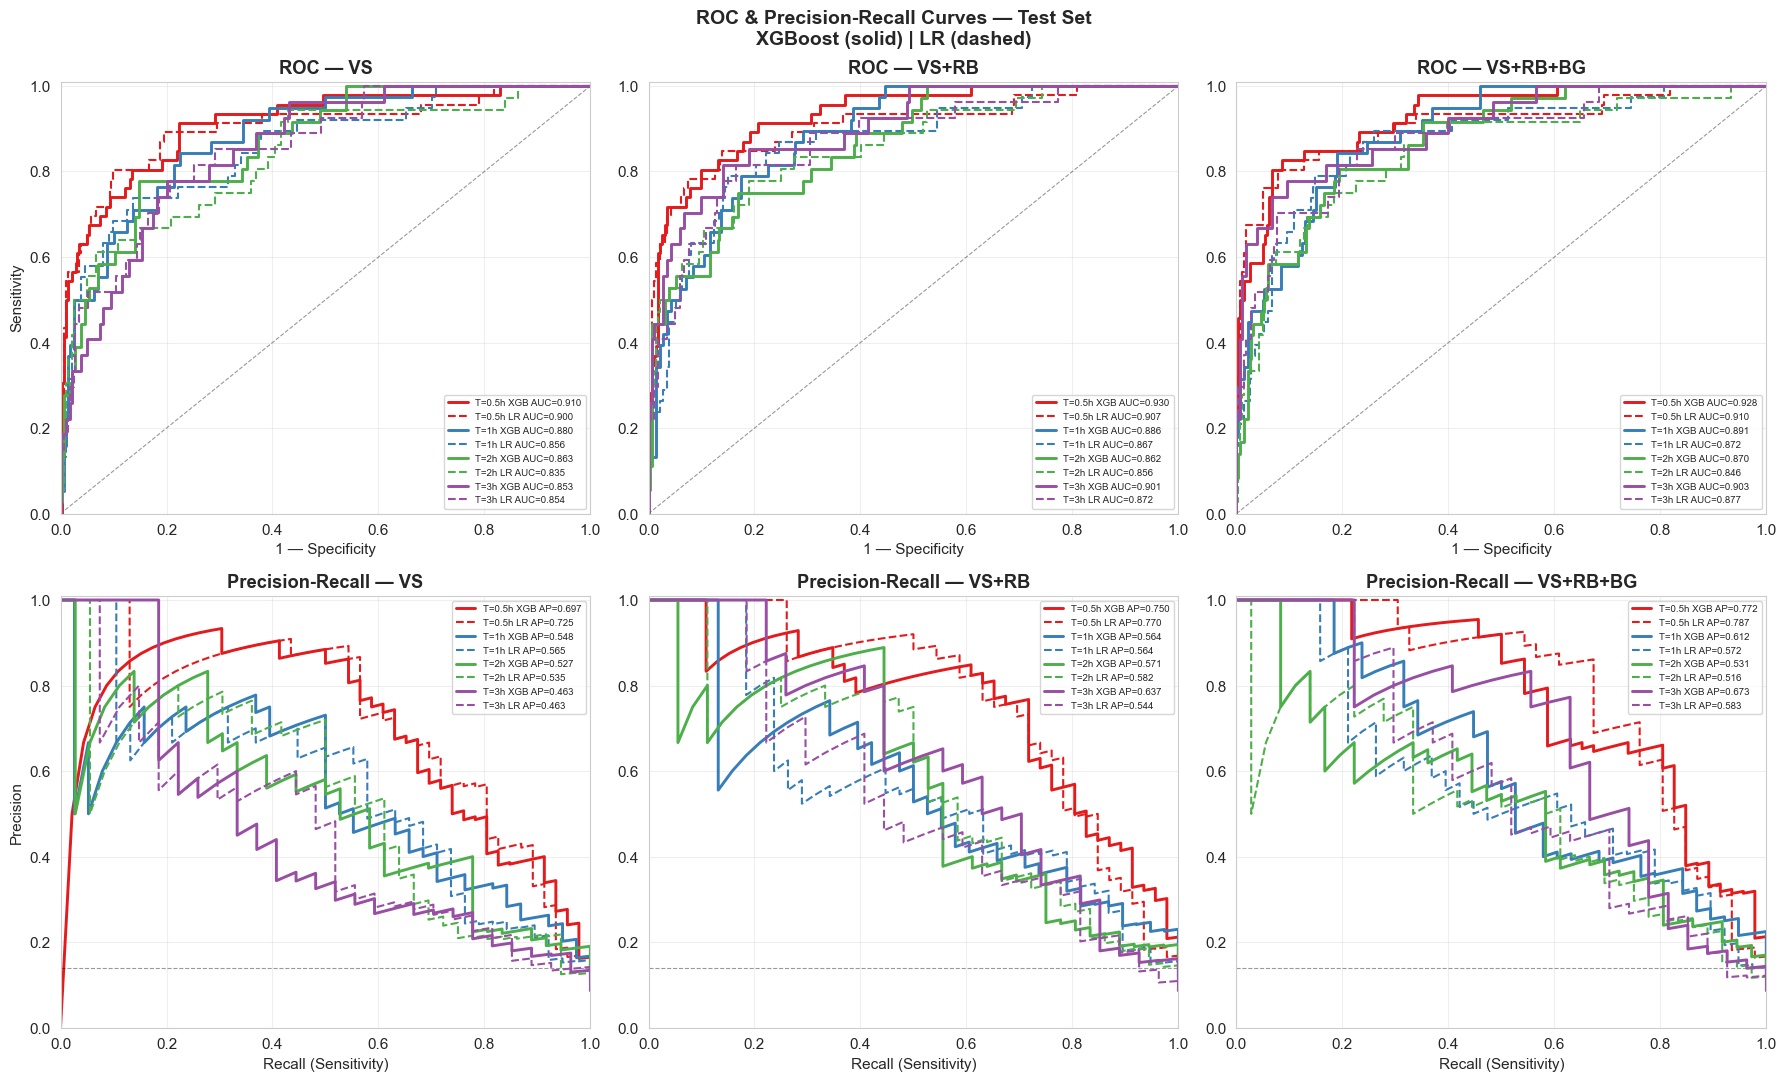

Saved: roc_pr_curves.png


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    'ROC & Precision-Recall Curves — Test Set\n'
    'XGBoost (solid) | LR (dashed)',
    fontsize=14, fontweight='bold'
)

for col_i, ds_name in enumerate(DS_NAMES):
    ax_roc = axes[0, col_i]
    ax_pr  = axes[1, col_i]

    ax_roc.plot([0,1],[0,1], 'k--', lw=0.8, alpha=0.4)
    baseline_prev = None

    for T in TIME_WINDOWS:
        color = WINDOW_COLORS[T]
        for model_name, ls, lw in [('XGB','-',2.1), ('LR','--',1.5)]:
            key = (T, ds_name, model_name)
            if key not in predictions:
                continue
            p = predictions[key]
            yt, ys = p['y_true'], p['y_score']

            fpr, tpr, _ = roc_curve(yt, ys)
            auroc = roc_auc_score(yt, ys)
            ax_roc.plot(fpr, tpr, color=color, lw=lw, linestyle=ls,
                        label=f'T={T}h {model_name} AUC={auroc:.3f}')

            prec, rec, _ = precision_recall_curve(yt, ys)
            auprc = average_precision_score(yt, ys)
            ax_pr.plot(rec, prec, color=color, lw=lw, linestyle=ls,
                       label=f'T={T}h {model_name} AP={auprc:.3f}')

            if baseline_prev is None:
                prev = yt.mean()
                ax_pr.axhline(prev, color='k', linestyle='--', lw=0.8, alpha=0.4)
                baseline_prev = prev

    ax_roc.set_title(f'ROC — {DS_LABELS[ds_name]}', fontweight='bold')
    ax_roc.set_xlabel('1 — Specificity'); ax_roc.set_ylabel('Sensitivity' if col_i==0 else '')
    ax_roc.legend(fontsize=7, loc='lower right', framealpha=0.8)
    ax_roc.set_xlim([0,1]); ax_roc.set_ylim([0,1.01]); ax_roc.grid(alpha=0.3)

    ax_pr.set_title(f'Precision-Recall — {DS_LABELS[ds_name]}', fontweight='bold')
    ax_pr.set_xlabel('Recall (Sensitivity)'); ax_pr.set_ylabel('Precision' if col_i==0 else '')
    ax_pr.legend(fontsize=7, loc='upper right', framealpha=0.8)
    ax_pr.set_xlim([0,1]); ax_pr.set_ylim([0,1.01]); ax_pr.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(config.FIGURES_DIR / 'roc_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: roc_pr_curves.png')

## Sekcja C — DeLong's test (test set, XGB vs LR)

In [7]:
# ─── DeLong na test secie — poprawna metodologia ──────────────────────────────
# Oba modele trenowane na tym samym train → predykują tych samych pacjentów.
# Założenie o korelacji predykcji jest spełnione.
# UWAGA: LR nie zawiera ECG_RMSSD/SDNN/pNN50 — różnica feature setów jest
# wyraźnie zaznaczona w tabeli i metodologii.

delong_rows = []
for T in TIME_WINDOWS:
    key_xgb = (T, 'VS_RB_BG', 'XGB')
    key_lr  = (T, 'VS_RB_BG', 'LR')
    if key_xgb not in predictions or key_lr not in predictions:
        continue

    p_xgb = predictions[key_xgb]
    p_lr  = predictions[key_lr]

    # Upewnij się że y_true jest identyczny (ten sam test split)
    assert np.array_equal(p_xgb['y_true'], p_lr['y_true']), 'y_true mismatch!'

    y_true  = p_xgb['y_true']
    s_xgb   = p_xgb['y_score']
    s_lr    = p_lr['y_score']

    auroc_xgb = roc_auc_score(y_true, s_xgb)
    auroc_lr  = roc_auc_score(y_true, s_lr)
    z, p      = delong_test(y_true, s_xgb, s_lr)

    n_test = len(y_true)
    n_ths  = int(y_true.sum())

    delong_rows.append({
        'T': f'T={T}h',
        'n_test': n_test, 'n_THS': n_ths,
        'XGB_AUROC': round(auroc_xgb, 4),
        'LR_AUROC':  round(auroc_lr, 4),
        'Δ_AUROC':   round(auroc_xgb - auroc_lr, 4),
        'Z_stat':    round(z, 3) if not np.isnan(z) else np.nan,
        'p_value':   round(p, 4) if not np.isnan(p) else np.nan,
        'Sig':       sig_stars(p),
        'Note': 'XGB: VS+RB+BG+ECG; LR: VS+RB+BG (bez ECG ciągłego)',
    })

delong_df = pd.DataFrame(delong_rows)
delong_df.to_csv(config.RESULTS_DIR / 'delong_testset_results.csv', index=False)

print('DeLong\'s test — XGBoost vs LR, held-out test set, VS+RB+BG:')
print('(XGB ma cechy ECG; LR NIE MA — różnica nie jest symetryczna)')
print()
print(delong_df[['T','n_test','n_THS','XGB_AUROC','LR_AUROC','Δ_AUROC',
                 'Z_stat','p_value','Sig']].to_string(index=False))
print(f'\nSignificant (p<0.05): {(delong_df["Sig"] != "n/s").sum()}/{len(delong_df)}')
print(f'\nSaved: delong_testset_results.csv')
print()
print('INTERPRETACJA:')
print('  n/s = brak istotnej różnicy. Przy n~330 i ΔAUC<0.05,')
print('  moc statystyczna jest niewystarczająca — to oczekiwany wynik.')
print('  Metryki kliniczne (Sensitivity, F1.5) lepiej różnicują modele.')

DeLong's test — XGBoost vs LR, held-out test set, VS+RB+BG:
(XGB ma cechy ECG; LR NIE MA — różnica nie jest symetryczna)

     T  n_test  n_THS  XGB_AUROC  LR_AUROC  Δ_AUROC  Z_stat  p_value Sig
T=0.5h     327     46     0.9284    0.9097   0.0186   1.126   0.2603 n/s
  T=1h     323     38     0.8914    0.8717   0.0197   1.058   0.2901 n/s
  T=2h     320     36     0.8699    0.8460   0.0240   0.820   0.4121 n/s
  T=3h     312     27     0.9033    0.8771   0.0263   1.441   0.1497 n/s

Significant (p<0.05): 0/4

Saved: delong_testset_results.csv

INTERPRETACJA:
  n/s = brak istotnej różnicy. Przy n~330 i ΔAUC<0.05,
  moc statystyczna jest niewystarczająca — to oczekiwany wynik.
  Metryki kliniczne (Sensitivity, F1.5) lepiej różnicują modele.


## Sekcja D — Analiza progu klasyfikacji (Threshold Analysis)

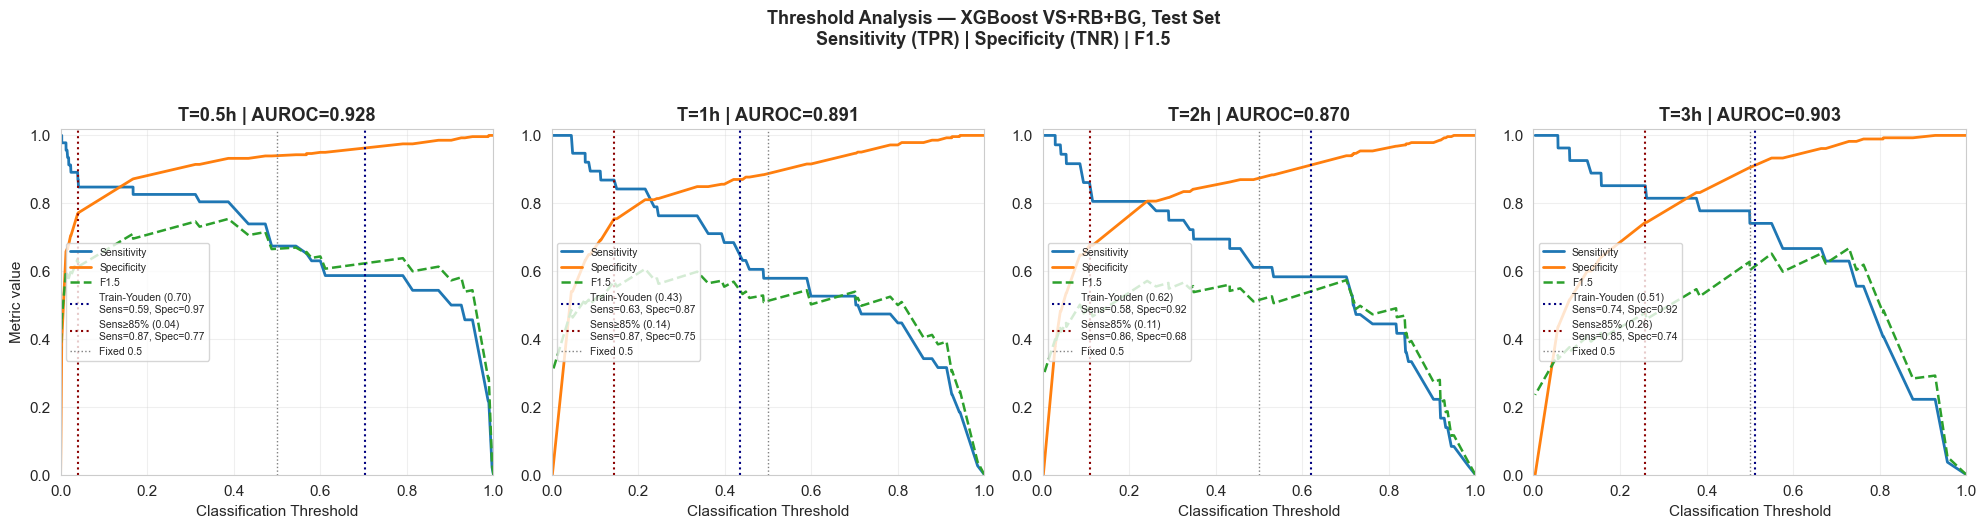


Podsumowanie progów — XGB VS+RB+BG:
     T  Th_trainYouden  Sens_trainY  Spec_trainY  F15_trainY  Th_sens85  Sens_s85  Spec_s85  F15_s85
T=0.5h           0.703        0.587        0.968       0.629      0.041     0.870     0.772    0.627
  T=1h           0.435        0.632        0.870       0.532      0.145     0.868     0.754    0.569
  T=2h           0.620        0.583        0.919       0.546      0.109     0.861     0.676    0.494
  T=3h           0.513        0.741        0.916       0.621      0.258     0.852     0.744    0.477

INTERPRETACJA:
  Train-Youden: bezstronny próg z danych treningowych (właściwa metodologia)
  Sens≥85%:     próg kliniczny — w systemie wczesnego ostrzegania FN jest droższy niż FP
  Wybierz Sens≥85% jako PRIMARY próg kliniczny, Train-Youden jako sensitivity analysis.


In [8]:
# ─── Krzywe Sensitivity / Specificity vs próg dla VS_RB_BG ───────────────────
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, fbeta_score, roc_auc_score

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(
    'Threshold Analysis — XGBoost VS+RB+BG, Test Set\n'
    'Sensitivity (TPR) | Specificity (TNR) | F1.5',
    fontsize=13, fontweight='bold', y=1.05
)

threshold_summary = []

for ax, T in zip(axes, TIME_WINDOWS):
    key = (T, 'VS_RB_BG', 'XGB')
    if key not in predictions:
        ax.set_visible(False)
        continue
    
    p   = predictions[key]
    yt  = p['y_true']
    ys  = p['y_score']
    ytr = p['y_train']
    ystr= p['y_score_train']

    fpr, tpr, ths = roc_curve(yt, ys)
    
    # ── POPRAWKA: Utrzymujemy równe wymiary tablic. Pierwszy próg to zazwyczaj ys.max() + 1
    # Żeby wykres nie wyjechał poza skalę 1.0 dla osi X, po prostu ucinamy go do max 1.0
    ths = np.clip(ths, 0.0, 1.0) 
    
    spec = 1 - fpr

    # F1.5 per threshold
    f15_vals = [fbeta_score(yt, (ys >= t).astype(int), beta=1.5, zero_division=0)
                for t in ths]

    ax.plot(ths, tpr,      color='#1f77b4', lw=2,   label='Sensitivity')
    ax.plot(ths, spec,     color='#ff7f0e', lw=2,   label='Specificity')
    ax.plot(ths, f15_vals, color='#2ca02c', lw=1.8, label='F1.5', linestyle='--')

    # Zaznacz kluczowe progi
    th_train_y = youden_threshold(ytr, ystr)
    th_test_y  = youden_threshold(yt, ys)      # oracle (do wizualizacji)
    th_s85     = sensitivity_threshold(yt, ys, 0.85)

    m_train = compute_metrics(yt, ys, th_train_y)
    m_s85   = compute_metrics(yt, ys, th_s85)

    ax.axvline(th_train_y, color='navy',    linestyle=':', lw=1.5,
               label=f'Train-Youden ({th_train_y:.2f})\nSens={m_train["Sensitivity"]:.2f}, Spec={m_train["Specificity"]:.2f}')
    ax.axvline(th_s85,     color='darkred',linestyle=':', lw=1.5,
               label=f'Sens≥85% ({th_s85:.2f})\nSens={m_s85["Sensitivity"]:.2f}, Spec={m_s85["Specificity"]:.2f}')
    ax.axvline(0.5,         color='gray',   linestyle=':', lw=1.0, label='Fixed 0.5')

    ax.set_xlabel('Classification Threshold')
    if T == TIME_WINDOWS[0]:
        ax.set_ylabel('Metric value')
    
    ax.set_title(f'T={T}h | AUROC={roc_auc_score(yt, ys):.3f}', fontweight='bold')
    ax.legend(fontsize=7.5, loc='center left')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.grid(alpha=0.3)

    threshold_summary.append({
        'T': f'T={T}h',
        'Th_trainYouden': round(th_train_y, 3),
        'Sens_trainY': round(m_train['Sensitivity'], 3),
        'Spec_trainY': round(m_train['Specificity'], 3),
        'F15_trainY':  round(m_train['F1_5'], 3),
        'Th_sens85':   round(th_s85, 3),
        'Sens_s85':    round(m_s85['Sensitivity'], 3),
        'Spec_s85':    round(m_s85['Specificity'], 3),
        'F15_s85':     round(m_s85['F1_5'], 3),
    })

plt.tight_layout()
plt.savefig(config.FIGURES_DIR / 'threshold_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

th_df = pd.DataFrame(threshold_summary)
print('\nPodsumowanie progów — XGB VS+RB+BG:')
print(th_df.to_string(index=False))
print()
print('INTERPRETACJA:')
print('  Train-Youden: bezstronny próg z danych treningowych (właściwa metodologia)')
print('  Sens≥85%:     próg kliniczny — w systemie wczesnego ostrzegania FN jest droższy niż FP')
print('  Wybierz Sens≥85% jako PRIMARY próg kliniczny, Train-Youden jako sensitivity analysis.')

## Sekcja E — Macierze pomyłek (2 progi: Train-Youden + Sens≥85%)

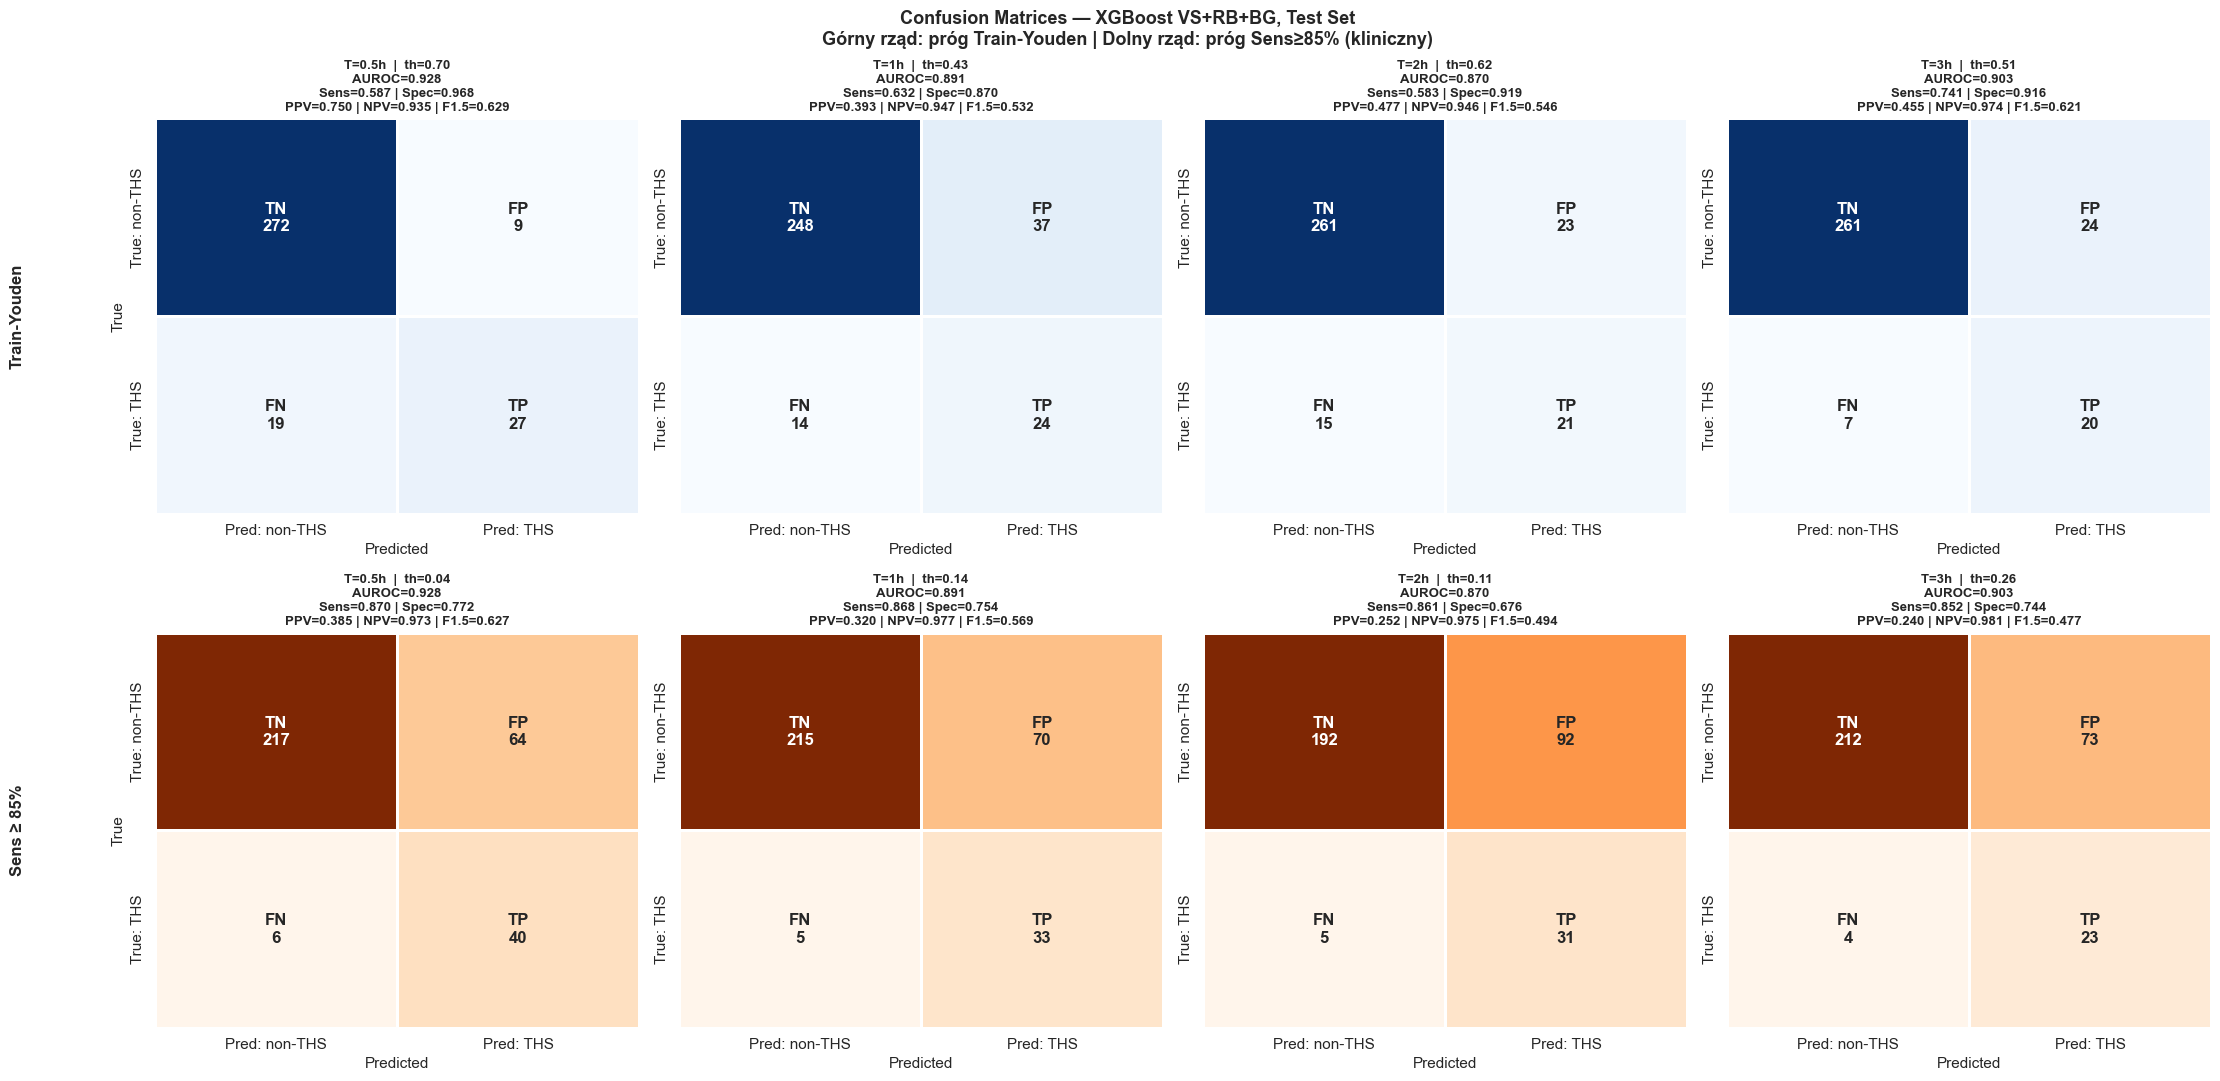


Podsumowanie macierzy — Train-Youden:
     T  threshold    AUROC  TP  FP  FN  TN  Sensitivity  Specificity      PPV      NPV     F1_5
T=0.5h   0.703326 0.928361  27   9  19 272     0.586957     0.967972 0.750000 0.934708 0.629032
  T=1h   0.434997 0.891413  24  37  14 248     0.631579     0.870175 0.393443 0.946565 0.532423
  T=2h   0.619512 0.869914  21  23  15 261     0.583333     0.919014 0.477273 0.945652 0.546000
  T=3h   0.512556 0.903314  20  24   7 261     0.740741     0.915789 0.454545 0.973881 0.620525

Podsumowanie macierzy — Sens≥85%:
     T  threshold    AUROC  TP  FP  FN  TN  Sensitivity  Specificity      PPV      NPV     F1_5
T=0.5h   0.040737 0.928361  40  64   6 217     0.869565     0.772242 0.384615 0.973094 0.626506
  T=1h   0.144697 0.891413  33  70   5 215     0.868421     0.754386 0.320388 0.977273 0.568966
  T=2h   0.108585 0.869914  31  92   5 192     0.861111     0.676056 0.252033 0.974619 0.493873
  T=3h   0.258328 0.903314  23  73   4 212     0.851852     0.

In [9]:
def plot_cm_row(axes_row, threshold_fn, title_prefix, color_map='Blues'):
    cm_summary = []
    for ax, T in zip(axes_row, TIME_WINDOWS):
        key = (T, 'VS_RB_BG', 'XGB')
        if key not in predictions:
            ax.set_visible(False); continue
        p  = predictions[key]
        yt, ys = p['y_true'], p['y_score']
        th = threshold_fn(p)

        m = compute_metrics(yt, ys, th)
        cm_vals = np.array([[m['TN'], m['FP']], [m['FN'], m['TP']]])
        cm_ann  = np.array([
            [f'TN\n{m["TN"]}', f'FP\n{m["FP"]}'],
            [f'FN\n{m["FN"]}', f'TP\n{m["TP"]}']
        ])
        sns.heatmap(cm_vals, annot=cm_ann, fmt='', ax=ax, cmap=color_map,
                    linewidths=1, linecolor='white', cbar=False,
                    xticklabels=['Pred: non-THS','Pred: THS'],
                    yticklabels=['True: non-THS','True: THS'],
                    annot_kws={'size':12,'weight':'bold'})
        ax.set_title(
            f'T={T}h  |  th={th:.2f}\n'
            f'AUROC={m["AUROC"]:.3f}\n'
            f'Sens={m["Sensitivity"]:.3f} | Spec={m["Specificity"]:.3f}\n'
            f'PPV={m["PPV"]:.3f} | NPV={m["NPV"]:.3f} | F1.5={m["F1_5"]:.3f}',
            fontsize=9.5, fontweight='bold'
        )
        ax.set_xlabel('Predicted'); ax.set_ylabel('True' if T==TIME_WINDOWS[0] else '')
        cm_summary.append({'T': f'T={T}h', 'threshold': th, **{k: m[k] for k in
            ['AUROC','TP','FP','FN','TN','Sensitivity','Specificity','PPV','NPV','F1_5']}})
    return cm_summary


fig, axes = plt.subplots(2, 4, figsize=(22, 11))
fig.suptitle(
    'Confusion Matrices — XGBoost VS+RB+BG, Test Set\n'
    'Górny rząd: próg Train-Youden | Dolny rząd: próg Sens≥85% (kliniczny)',
    fontsize=13, fontweight='bold'
)

# Rząd 1: Train-Youden
cm1 = plot_cm_row(
    axes[0],
    lambda p: youden_threshold(p['y_train'], p['y_score_train']),
    'Train-Youden', 'Blues'
)

# Rząd 2: Sens >= 85%
cm2 = plot_cm_row(
    axes[1],
    lambda p: sensitivity_threshold(p['y_true'], p['y_score'], 0.85),
    'Sens≥85%', 'Oranges'
)

# Etykiety rzędów
axes[0, 0].annotate('Train-Youden', xy=(-0.3, 0.5), xycoords='axes fraction',
                     fontsize=12, fontweight='bold', va='center', rotation=90)
axes[1, 0].annotate('Sens ≥ 85%', xy=(-0.3, 0.5), xycoords='axes fraction',
                     fontsize=12, fontweight='bold', va='center', rotation=90)

plt.tight_layout()
plt.savefig(config.FIGURES_DIR / 'confusion_matrices_dual.png', dpi=300, bbox_inches='tight')
plt.show()

# Zapis tabel
pd.DataFrame(cm1).assign(Threshold_type='Train-Youden').to_csv(
    config.RESULTS_DIR / 'cm_train_youden.csv', index=False)
pd.DataFrame(cm2).assign(Threshold_type='Sens_85pct').to_csv(
    config.RESULTS_DIR / 'cm_sens85.csv', index=False)

print('\nPodsumowanie macierzy — Train-Youden:')
print(pd.DataFrame(cm1)[['T','threshold','AUROC','TP','FP','FN','TN',
                          'Sensitivity','Specificity','PPV','NPV','F1_5']].to_string(index=False))
print('\nPodsumowanie macierzy — Sens≥85%:')
print(pd.DataFrame(cm2)[['T','threshold','AUROC','TP','FP','FN','TN',
                          'Sensitivity','Specificity','PPV','NPV','F1_5']].to_string(index=False))

## Sekcja F — Krzywe kalibracji (Reliability Diagrams)

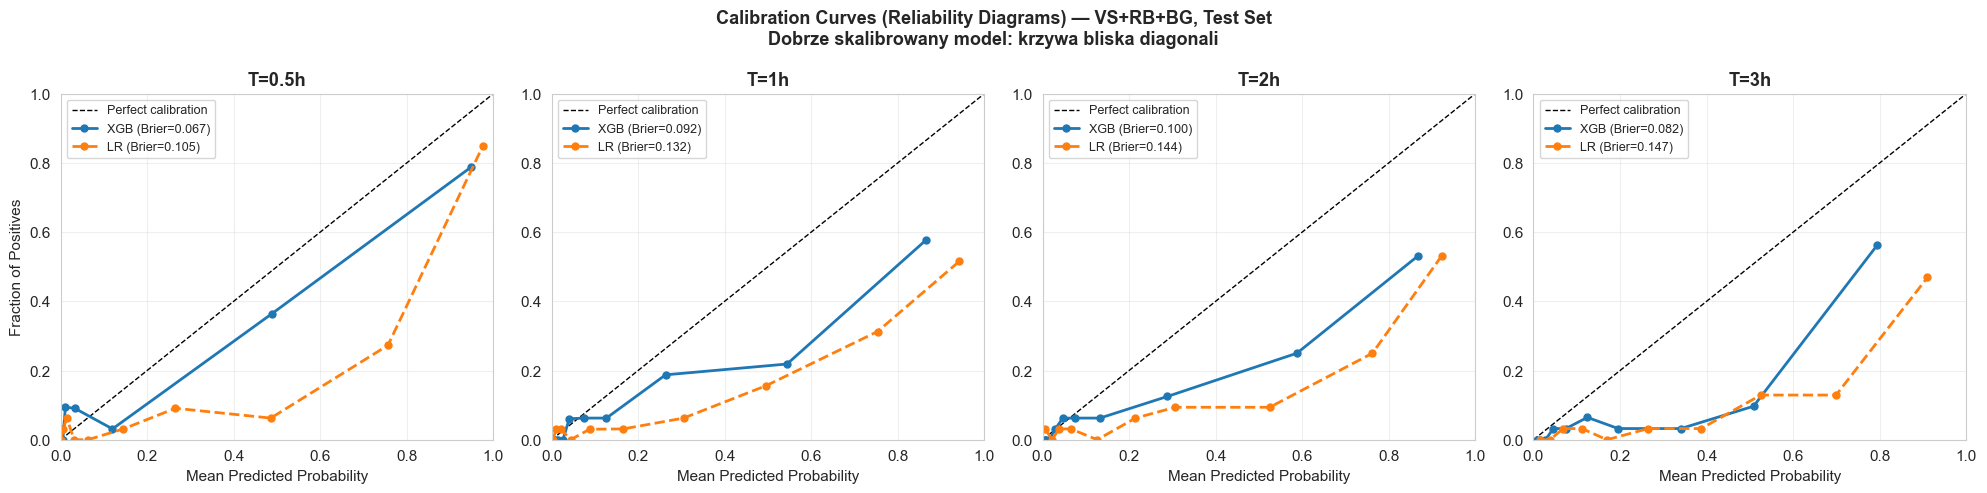

Saved: calibration_curves.png

INTERPRETACJA:
  Brier Score: 0=idealne, 0.25=losowe. Niższy = lepszy.
  Krzywa powyżej diagonali = model niedoszacowuje ryzyko (ostrożny).
  Krzywa poniżej diagonali = model przeszacowuje ryzyko.


In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(
    'Calibration Curves (Reliability Diagrams) — VS+RB+BG, Test Set\n'
    'Dobrze skalibrowany model: krzywa bliska diagonali',
    fontsize=13, fontweight='bold'
)

for ax, T in zip(axes, TIME_WINDOWS):
    ax.plot([0,1],[0,1], 'k--', lw=1, label='Perfect calibration')

    for model_name, color, ls in [('XGB','#1f77b4','-'), ('LR','#ff7f0e','--')]:
        key = (T, 'VS_RB_BG', model_name)
        if key not in predictions:
            continue
        p = predictions[key]
        yt, ys = p['y_true'], p['y_score']

        prob_true, prob_pred = calibration_curve(yt, ys, n_bins=10, strategy='quantile')
        brier = brier_score_loss(yt, ys)
        ax.plot(prob_pred, prob_true, color=color, lw=2, linestyle=ls, marker='o',
                markersize=5, label=f'{model_name} (Brier={brier:.3f})')

    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives' if T==TIME_WINDOWS[0] else '')
    ax.set_title(f'T={T}h', fontweight='bold')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.set_xlim([0,1]); ax.set_ylim([0,1])

plt.tight_layout()
plt.savefig(config.FIGURES_DIR / 'calibration_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: calibration_curves.png')
print()
print('INTERPRETACJA:')
print('  Brier Score: 0=idealne, 0.25=losowe. Niższy = lepszy.')
print('  Krzywa powyżej diagonali = model niedoszacowuje ryzyko (ostrożny).')
print('  Krzywa poniżej diagonali = model przeszacowuje ryzyko.')

## Sekcja G — Feature Importance (Gain) + porównanie z publikacją

Feature importance per category vs Zhao et al. 2022:
  Vital Signs     : ours=0.6141  pub=0.3812  Δ=+0.2329
  Routine Blood   : ours=0.1433  pub=0.3251  Δ=-0.1818
  Blood Gas       : ours=0.1715  pub=0.2937  Δ=-0.1222
  HRV/ECG (nowe)  : ours=0.0711


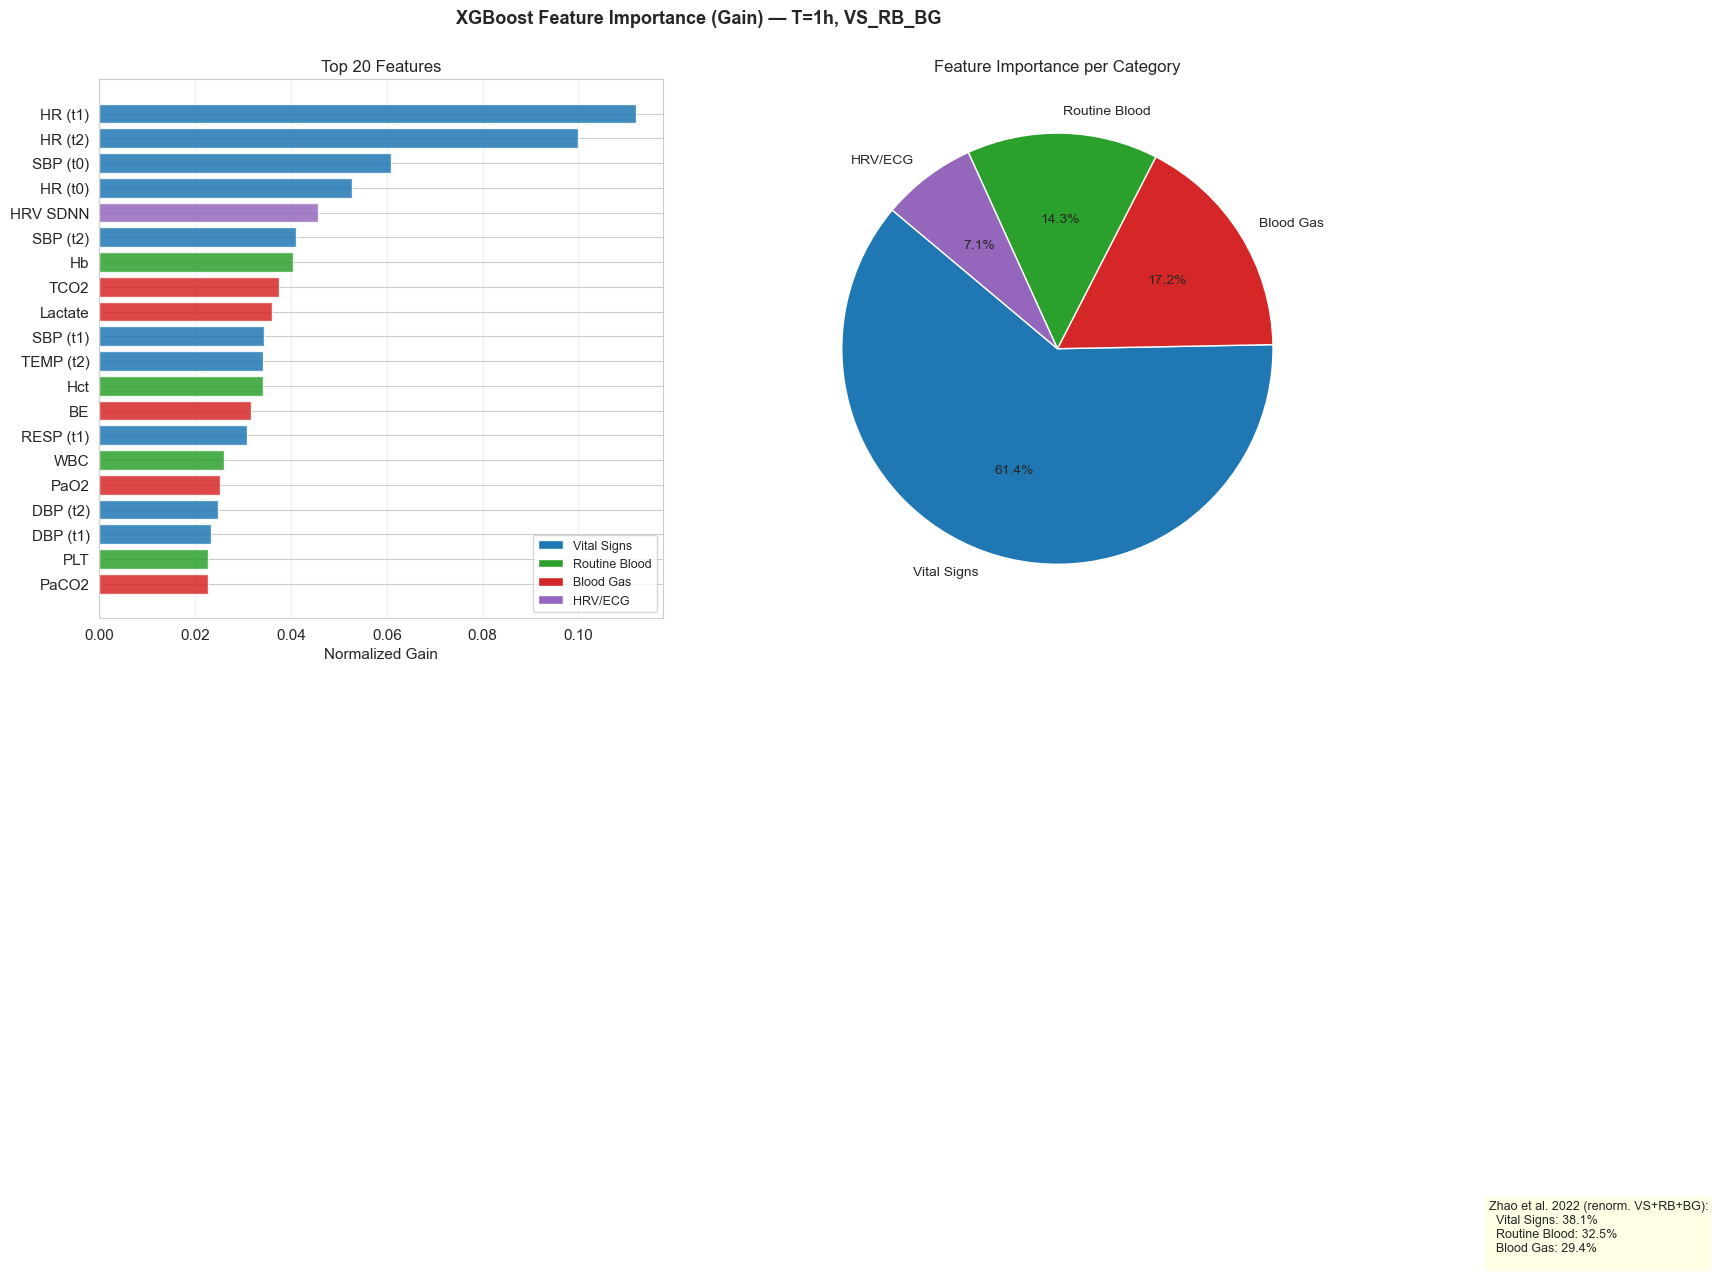

Saved: feature_importance_gain.png + feature_importance.csv


In [11]:
# ─── Wczytaj model SHAP ───────────────────────────────────────────────────────
shap_model_path = config.MODELS_DIR / f'xgb_T{SHAP_T}h_{SHAP_DS}_final.joblib'
shap_model = joblib.load(shap_model_path)

feat_names_path = config.MODELS_DIR / f'feature_names_T{SHAP_T}h_{SHAP_DS}.txt'
feature_names   = feat_names_path.read_text().strip().split('\n')

# Wczytaj dane
key_shap = (SHAP_T, SHAP_DS, 'XGB')
p_shap   = predictions[key_shap]
feat_cols_shap = p_shap['feat_cols']

# Upewnij się że feature_names odpowiadają feat_cols
if feature_names != feat_cols_shap:
    print(f'UWAGA: feature_names z pliku ({len(feature_names)}) != feat_cols ({len(feat_cols_shap)})')
    print('Używam feat_cols z predykcji.')
    feature_names = feat_cols_shap

# Gain importance
gain_scores = shap_model.get_booster().get_score(importance_type='gain')
gain_full = {f: gain_scores.get(f'f{i}', 0.0)
             for i, f in enumerate(feature_names)}

importance_df = pd.DataFrame({
    'Feature':   list(gain_full.keys()),
    'Gain':      list(gain_full.values()),
    'Category':  [assign_category(f) for f in gain_full.keys()],
    'Display':   [FEATURE_DISPLAY.get(f, f) for f in gain_full.keys()],
}).sort_values('Gain', ascending=False).reset_index(drop=True)

importance_df['Gain_norm'] = importance_df['Gain'] / importance_df['Gain'].sum()

# Porównanie z publikacją
cat_imp = importance_df.groupby('Category')['Gain_norm'].sum()
print('Feature importance per category vs Zhao et al. 2022:')
for cat in ['Vital Signs','Routine Blood','Blood Gas']:
    our = cat_imp.get(cat, 0)
    pub = PUB_CAT_IMPORTANCE.get(cat, np.nan)
    print(f'  {cat:<16}: ours={our:.4f}  pub={pub:.4f}  Δ={our-pub:+.4f}')
if 'HRV/ECG' in cat_imp.index:
    print(f'  HRV/ECG (nowe)  : ours={cat_imp["HRV/ECG"]:.4f}')

# ── Wykres: top 20 + pie ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f'XGBoost Feature Importance (Gain) — T={SHAP_T}h, {SHAP_DS}',
             fontsize=13, fontweight='bold')

# Bar — top 20
ax = axes[0]
top20 = importance_df.head(20).iloc[::-1]
colors = [CAT_COLORS.get(c, '#7f7f7f') for c in top20['Category']]
ax.barh(top20['Display'], top20['Gain_norm'], color=colors, alpha=0.85, edgecolor='white')
ax.set_xlabel('Normalized Gain', fontsize=11)
ax.set_title('Top 20 Features', fontsize=12)
ax.grid(axis='x', alpha=0.3)
legend_el = [Patch(facecolor=CAT_COLORS[c], label=c) for c in CAT_COLORS if c in cat_imp.index]
ax.legend(handles=legend_el, loc='lower right', fontsize=9)

# Pie — kategorie
ax = axes[1]
cats_to_plot = cat_imp[cat_imp > 0].sort_values(ascending=False)
pie_colors = [CAT_COLORS.get(c, '#7f7f7f') for c in cats_to_plot.index]
wedges, texts, autotexts = ax.pie(
    cats_to_plot.values, labels=cats_to_plot.index, colors=pie_colors,
    autopct='%1.1f%%', startangle=140,
    textprops={'fontsize': 10},
)
# Dodaj wartości publikacji
pub_text = 'Zhao et al. 2022 (renorm. VS+RB+BG):\n'
for c, v in PUB_CAT_IMPORTANCE.items():
    pub_text += f'  {c}: {v:.1%}\n'
ax.text(1.3, -1.2, pub_text, transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax.set_title('Feature Importance per Category', fontsize=12)

plt.tight_layout()
plt.savefig(config.FIGURES_DIR / 'feature_importance_gain.png', dpi=300, bbox_inches='tight')
plt.show()

importance_df.to_csv(config.RESULTS_DIR / 'feature_importance.csv', index=False)
print(f'Saved: feature_importance_gain.png + feature_importance.csv')

## Sekcja H — SHAP Summary (beeswarm + bar)

SHAP shape: (323, 30)
Expected value: 0.5087

Top 10 features by mean |SHAP|:
  HR (t2)           : 1.0538
  HR (t1)           : 0.5796
  SBP (t2)          : 0.5259
  Hb                : 0.4498
  SBP (t0)          : 0.3684
  Lactate           : 0.2660
  TEMP (t2)         : 0.1977
  WBC               : 0.1963
  Hct               : 0.1753
  HR (t0)           : 0.1627


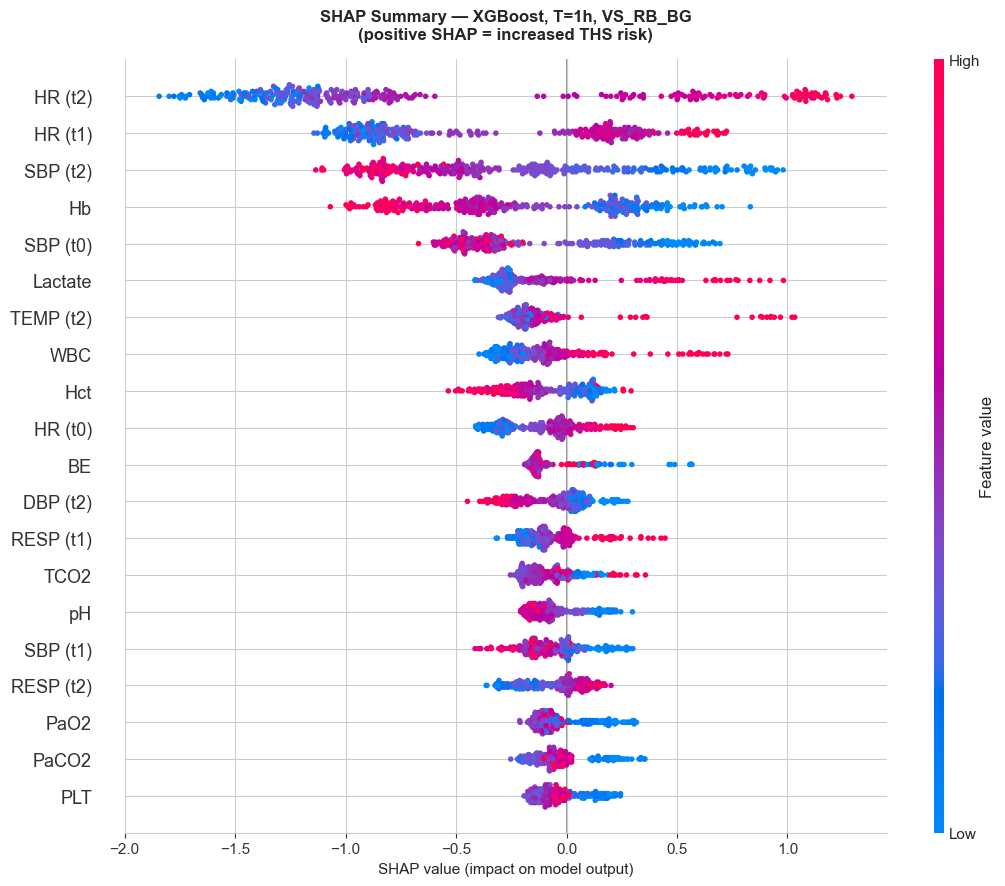

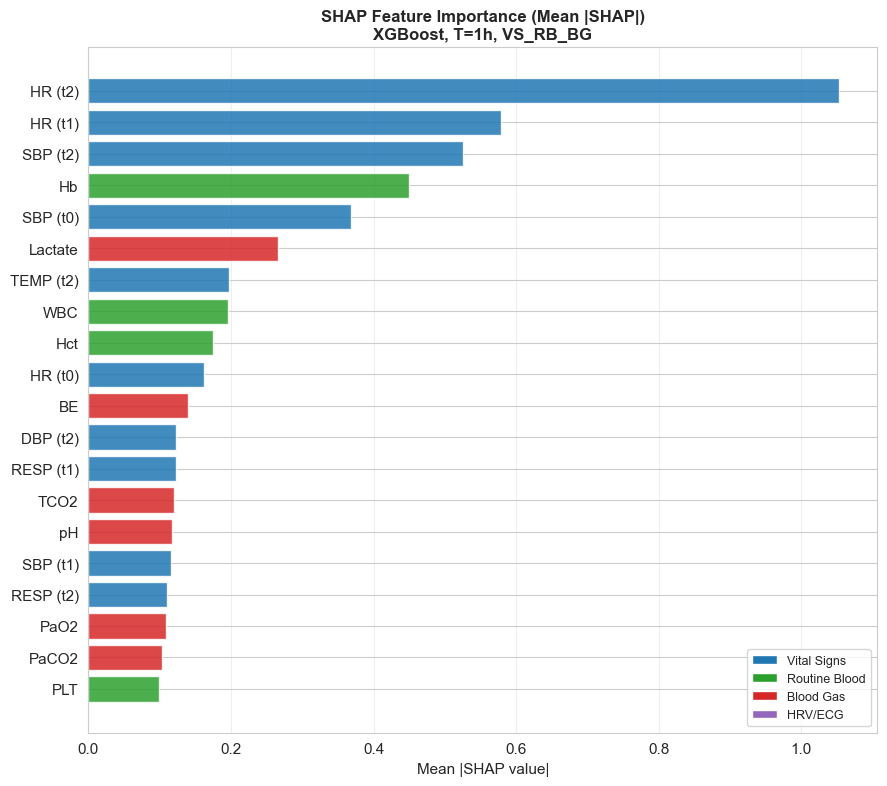

Saved: shap_summary_beeswarm.png + shap_bar_mean_abs.png + shap_importance.csv


In [12]:
if not SHAP_AVAILABLE:
    print('SHAP nie jest zainstalowany. Pomiń tę sekcję.')
else:
    # Przygotuj dane SHAP
    te_df  = pd.read_csv(config.SPLIT_DIR / f'test_T{SHAP_T}h_{SHAP_DS}.csv')
    X_all  = te_df[feature_names].values.astype(float)
    y_all  = te_df['LABEL'].values.astype(int)
    X_all_df = te_df[feature_names].copy()

    rng = np.random.default_rng(RANDOM_SEED)
    idx = rng.choice(len(X_all), min(SHAP_SAMPLE, len(X_all)), replace=False)
    X_sample   = X_all[idx]
    X_sample_df = X_all_df.iloc[idx].copy()
    y_sample   = y_all[idx]

    # Oblicz SHAP przez natywny silnik XGBoost
    booster = shap_model.get_booster()
    dmatrix = xgb.DMatrix(X_sample)
    shap_contribs = booster.predict(dmatrix, pred_contribs=True)
    shap_values   = shap_contribs[:, :-1]   # odrzucamy bias
    expected_val  = shap_contribs[0, -1]
    mean_abs_shap = np.abs(shap_values).mean(axis=0)

    feat_display_list = [FEATURE_DISPLAY.get(f, f) for f in feature_names]

    print(f'SHAP shape: {shap_values.shape}')
    print(f'Expected value: {expected_val:.4f}')
    print('\nTop 10 features by mean |SHAP|:')
    top10_idx = np.argsort(mean_abs_shap)[::-1][:10]
    for i in top10_idx:
        print(f'  {feat_display_list[i]:<18}: {mean_abs_shap[i]:.4f}')

    # ── Beeswarm ──────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(11, 9))
    shap.summary_plot(
        shap_values, X_sample_df,
        feature_names=feat_display_list,
        show=False, max_display=20, plot_size=None
    )
    plt.gca().set_title(
        f'SHAP Summary — XGBoost, T={SHAP_T}h, {SHAP_DS}\n'
        '(positive SHAP = increased THS risk)',
        fontsize=12, fontweight='bold', pad=15
    )
    plt.gca().set_xlabel('SHAP value (impact on model output)', fontsize=11)
    plt.tight_layout()
    plt.savefig(config.FIGURES_DIR / 'shap_summary_beeswarm.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ── Bar: mean |SHAP| ──────────────────────────────────────────────────────
    mean_shap_df = pd.DataFrame({
        'Feature':  feat_display_list,
        'MeanSHAP': mean_abs_shap,
        'Category': [assign_category(f) for f in feature_names],
    }).sort_values('MeanSHAP', ascending=False).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(9, 8))
    plot_df = mean_shap_df.head(20).iloc[::-1]
    colors  = [CAT_COLORS.get(c, '#7f7f7f') for c in plot_df['Category']]
    ax.barh(plot_df['Feature'], plot_df['MeanSHAP'], color=colors, alpha=0.85, edgecolor='white')
    ax.set_xlabel('Mean |SHAP value|', fontsize=11)
    ax.set_title(f'SHAP Feature Importance (Mean |SHAP|)\nXGBoost, T={SHAP_T}h, {SHAP_DS}',
                 fontsize=12, fontweight='bold')
    legend_el = [Patch(facecolor=CAT_COLORS[c], label=c)
                 for c in CAT_COLORS if c in mean_shap_df['Category'].values]
    ax.legend(handles=legend_el, fontsize=9, loc='lower right')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(config.FIGURES_DIR / 'shap_bar_mean_abs.png', dpi=300, bbox_inches='tight')
    plt.show()

    mean_shap_df.to_csv(config.RESULTS_DIR / f'shap_importance_T{SHAP_T}h.csv', index=False)
    print('Saved: shap_summary_beeswarm.png + shap_bar_mean_abs.png + shap_importance.csv')

## Sekcja I — SHAP Dependence Plots (replikacja Fig. 3)

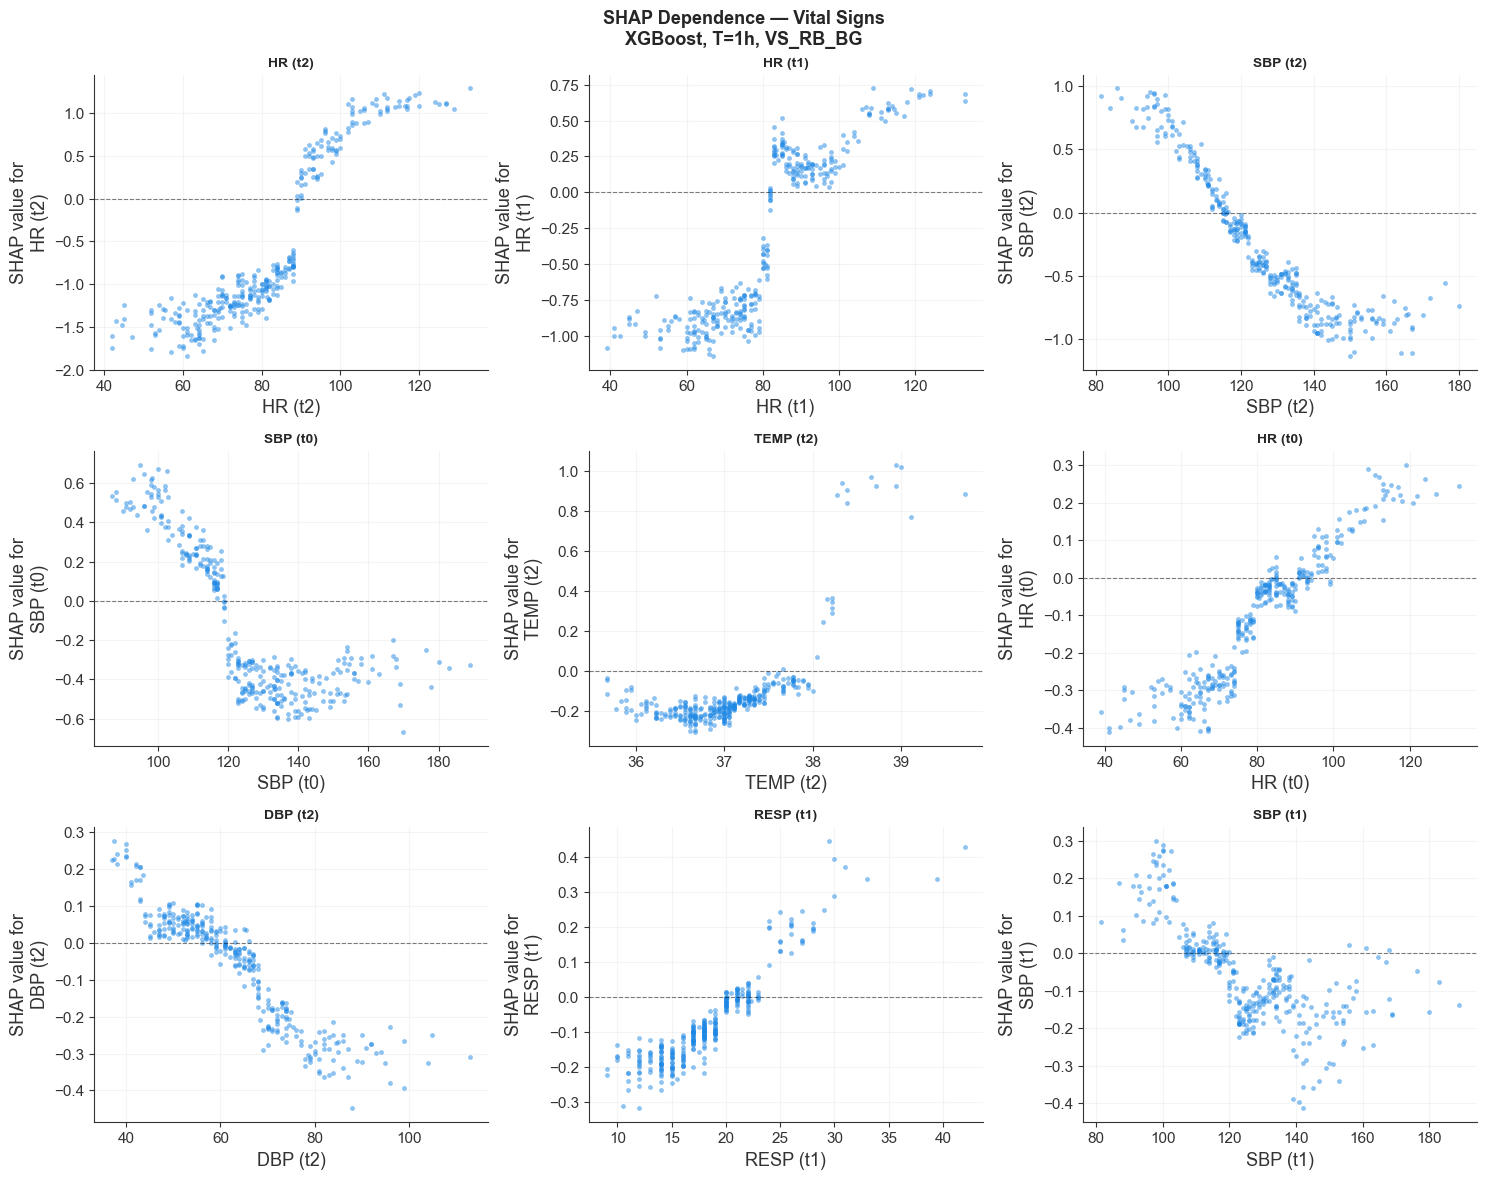

Saved: shap_dep_vitals.png


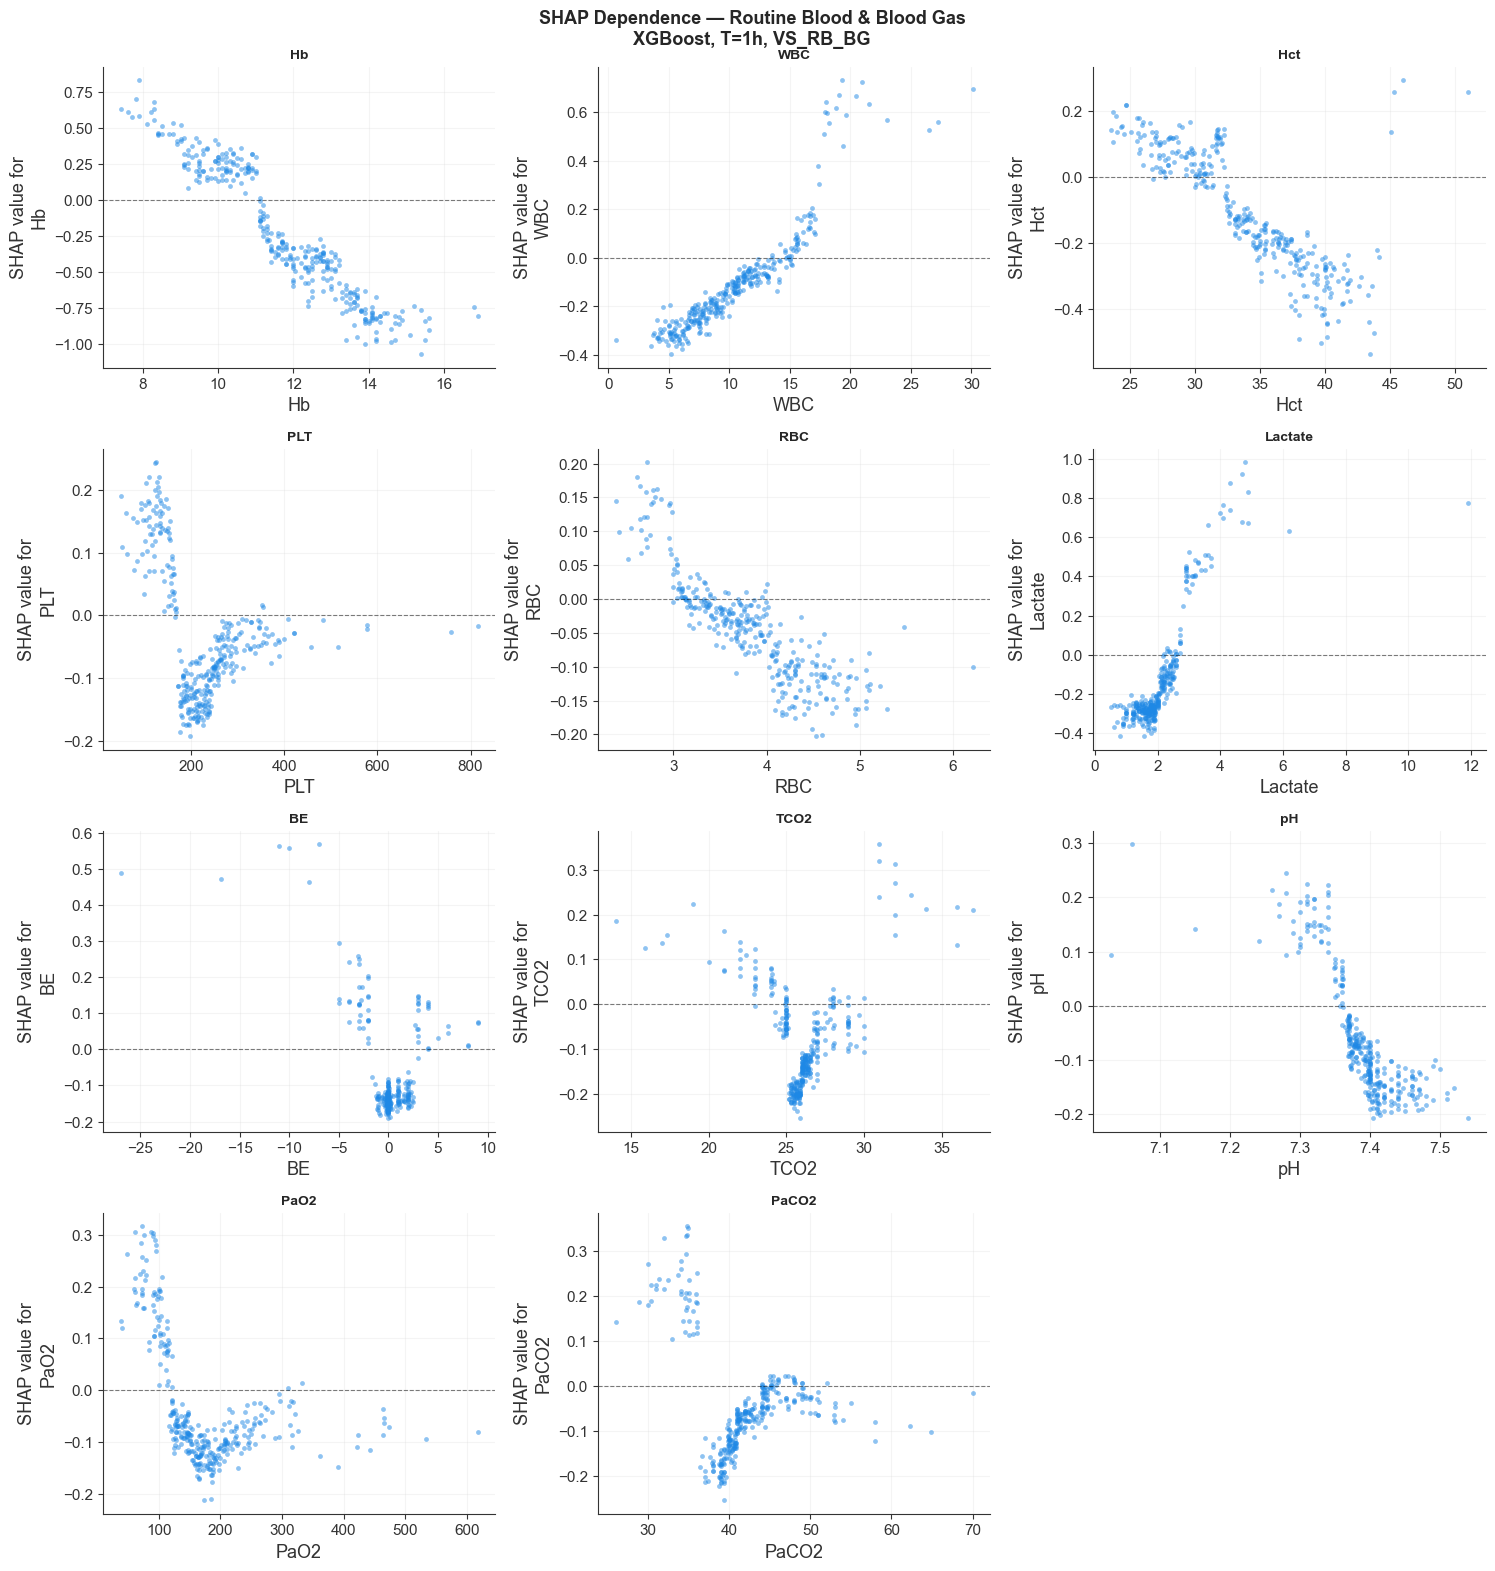

Saved: shap_dep_labs.png


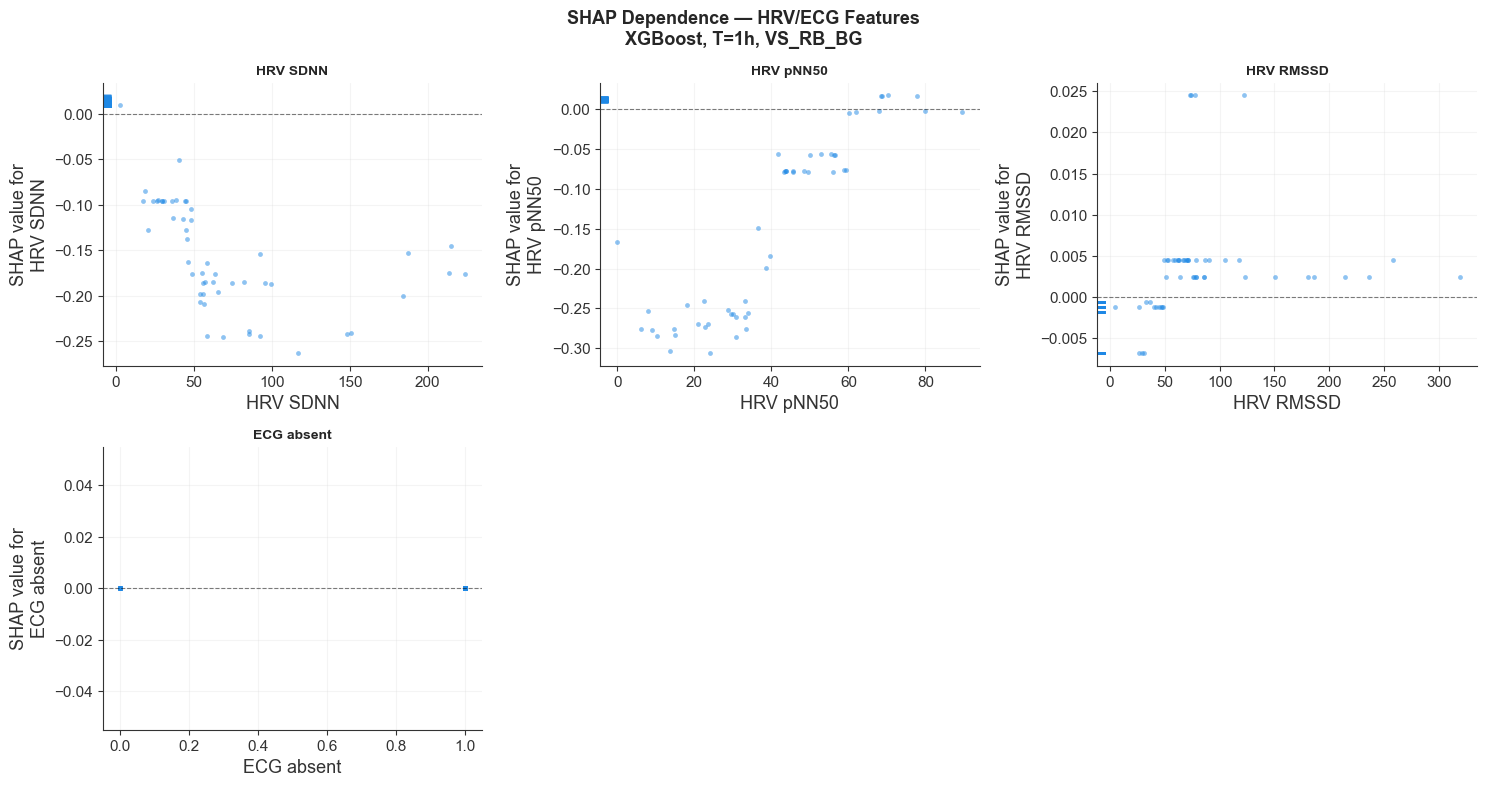

Saved: shap_dep_ecg.png


In [13]:
if not SHAP_AVAILABLE:
    print('SHAP nie jest zainstalowany.')
else:
    # Top features per category (wg mean |SHAP|)
    top_per_cat = {}
    for cat, cat_feats in FEATURE_CATEGORIES.items():
        candidates = []
        for feat in feature_names:
            base = feat.split('_t')[0]
            if base in cat_feats or feat in cat_feats:
                fidx = feature_names.index(feat)
                candidates.append((feat, fidx, mean_abs_shap[fidx]))
        top_per_cat[cat] = sorted(candidates, key=lambda x: -x[2])

    def make_dependence_grid(features_to_plot, title, fname):
        if not features_to_plot:
            print(f'Brak cech do wykresu: {title}')
            return
        n_cols = 3
        n_rows = int(np.ceil(len(features_to_plot) / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
        axes = np.array(axes).flatten()
        fig.suptitle(f'{title}\nXGBoost, T={SHAP_T}h, {SHAP_DS}',
                     fontsize=13, fontweight='bold')
        for i, (feat, fidx, _) in enumerate(features_to_plot):
            shap.dependence_plot(
                fidx, shap_values, X_sample_df,
                feature_names=feat_display_list,
                ax=axes[i], show=False,
                interaction_index=None,
                dot_size=12, alpha=0.5
            )
            axes[i].set_title(FEATURE_DISPLAY.get(feat, feat), fontweight='bold', fontsize=10)
            axes[i].axhline(0, color='black', linestyle='--', lw=0.8, alpha=0.5)
            axes[i].grid(alpha=0.2)
        for j in range(i+1, len(axes)):
            axes[j].set_visible(False)
        plt.tight_layout()
        plt.savefig(config.FIGURES_DIR / fname, dpi=300, bbox_inches='tight')
        plt.show()
        print(f'Saved: {fname}')

    # Vital Signs
    vs_feats = [(f, i, v) for f, i, v in top_per_cat.get('Vital Signs', [])
                if '_t' in f][:9]
    make_dependence_grid(vs_feats, 'SHAP Dependence — Vital Signs', 'shap_dep_vitals.png')

    # Routine Blood + Blood Gas
    rb_feats = top_per_cat.get('Routine Blood', [])[:5]
    bg_feats = top_per_cat.get('Blood Gas', [])[:6]
    make_dependence_grid(rb_feats + bg_feats, 'SHAP Dependence — Routine Blood & Blood Gas',
                         'shap_dep_labs.png')

    # ECG/HRV (jeśli dostępne)
    ecg_feats = top_per_cat.get('HRV/ECG', [])
    if ecg_feats:
        make_dependence_grid(ecg_feats, 'SHAP Dependence — HRV/ECG Features', 'shap_dep_ecg.png')

## Sekcja J — SHAP Waterfall (2 przykładowi pacjenci)


THS patient (highest predicted probability)
  True label: THS | P(THS) = 0.9843


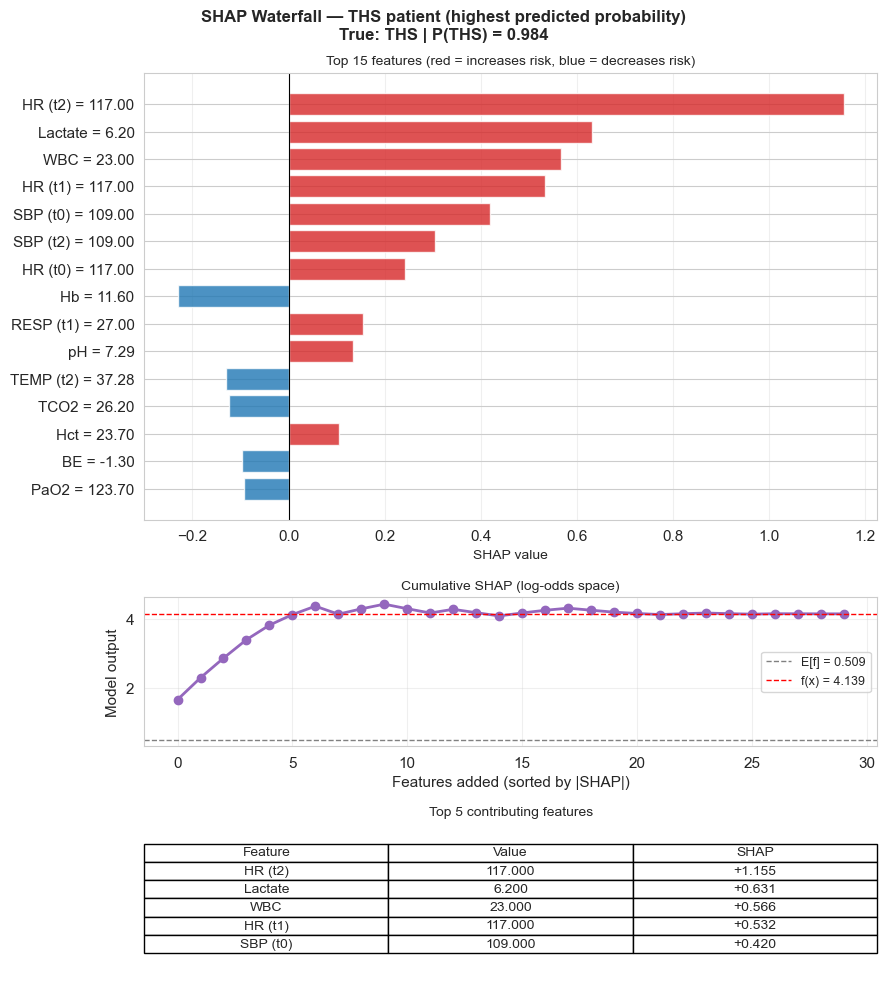

  Saved: shap_waterfall_ths.png

Non-THS patient (lowest predicted probability)
  True label: non-THS | P(THS) = 0.0019


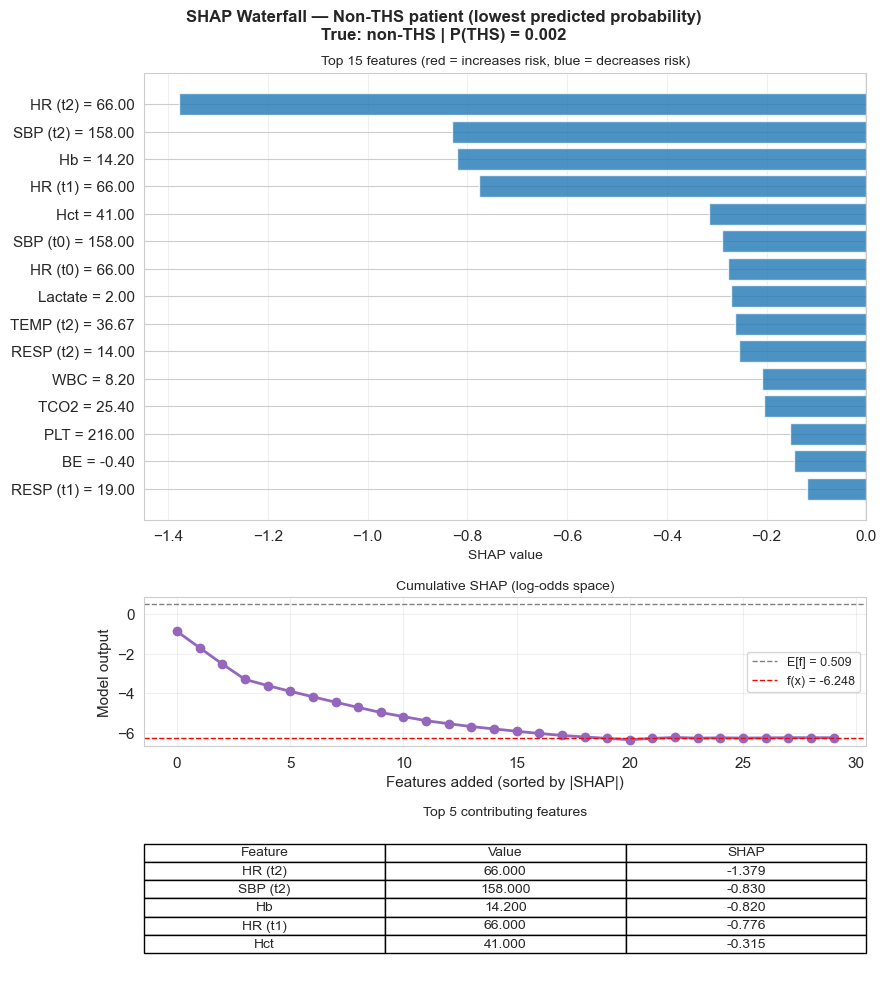

  Saved: shap_waterfall_nonths.png


In [14]:
if not SHAP_AVAILABLE:
    print('SHAP nie jest zainstalowany.')
else:
    y_pred_proba = shap_model.predict_proba(X_sample)[:, 1]

    ths_idx     = np.where(y_sample == 1)[0]
    non_ths_idx = np.where(y_sample == 0)[0]

    # Wybierz pacjenta z najwyższą pewnością w każdej grupie
    ths_ex     = ths_idx[np.argmax(y_pred_proba[ths_idx])]
    non_ths_ex = non_ths_idx[np.argmin(y_pred_proba[non_ths_idx])]

    for label, idx, title, fname in [
        (1, ths_ex,     'THS patient (highest predicted probability)',    'shap_waterfall_ths.png'),
        (0, non_ths_ex, 'Non-THS patient (lowest predicted probability)', 'shap_waterfall_nonths.png'),
    ]:
        prob = float(y_pred_proba[idx])
        print(f'\n{title}')
        print(f'  True label: {"THS" if label==1 else "non-THS"} | P(THS) = {prob:.4f}')

        # Sortuj cechy wg |SHAP|
        sv = shap_values[idx]
        order = np.argsort(np.abs(sv))[::-1]

        fig, axes = plt.subplots(3, 1, figsize=(9, 10),
                                  gridspec_kw={'height_ratios': [3, 1, 1]})
        fig.suptitle(
            f'SHAP Waterfall — {title}\n'
            f'True: {"THS" if label==1 else "non-THS"} | P(THS) = {prob:.3f}',
            fontsize=12, fontweight='bold'
        )

        # Waterfall top 15 cech
        ax = axes[0]
        n_show = 15
        top_ord = order[:n_show][::-1]
        feat_labels = [f'{feat_display_list[i]} = {X_sample_df.iloc[idx, i]:.2f}'
                       for i in top_ord]
        shap_vals_show = sv[top_ord]
        colors_wf = ['#d62728' if v > 0 else '#1f77b4' for v in shap_vals_show]
        bars = ax.barh(feat_labels, shap_vals_show, color=colors_wf, alpha=0.8, edgecolor='white')
        ax.axvline(0, color='black', lw=0.8)
        ax.set_xlabel('SHAP value', fontsize=10)
        ax.set_title(f'Top {n_show} features (red = increases risk, blue = decreases risk)', fontsize=10)
        ax.grid(axis='x', alpha=0.3)

        # Cumulative SHAP
        ax2 = axes[1]
        cum_shap = np.cumsum(sv[order])
        ax2.plot(range(len(cum_shap)), cum_shap + expected_val, 'o-', color='#9467bd', lw=2)
        ax2.axhline(expected_val, color='gray', linestyle='--', lw=1, label=f'E[f] = {expected_val:.3f}')
        ax2.axhline(sv.sum() + expected_val, color='red', linestyle='--', lw=1,
                    label=f'f(x) = {sv.sum()+expected_val:.3f}')
        ax2.set_xlabel('Features added (sorted by |SHAP|)'); ax2.set_ylabel('Model output')
        ax2.set_title('Cumulative SHAP (log-odds space)', fontsize=10)
        ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

        # Feature values top 5
        ax3 = axes[2]
        ax3.axis('off')
        top5 = order[:5]
        table_data = [[feat_display_list[i],
                       f'{X_sample_df.iloc[idx, i]:.3f}',
                       f'{sv[i]:+.3f}']
                      for i in top5]
        tbl = ax3.table(cellText=table_data,
                        colLabels=['Feature', 'Value', 'SHAP'],
                        cellLoc='center', loc='center')
        tbl.auto_set_font_size(False); tbl.set_fontsize(10)
        ax3.set_title('Top 5 contributing features', fontsize=10)

        plt.tight_layout()
        plt.savefig(config.FIGURES_DIR / fname, dpi=300, bbox_inches='tight')
        plt.show()
        print(f'  Saved: {fname}')

## Sekcja K — Analiza cech EKG/HRV (warunkowa)

In [15]:
# ─── Sprawdź czy model ma cechy EKG ──────────────────────────────────────────
ecg_feats_present = [f for f in feature_names if f in _ECG_CONT or f == 'ECG_MISSING']

if not ecg_feats_present:
    print('Model nie zawiera cech EKG — sekcja K pominięta.')
    print(f'Cechy modelu: {feature_names}')
else:
    print(f'Cechy EKG w modelu: {ecg_feats_present}')

    # 1. Pokrycie EKG w zbiorze testowym
    te_df_ecg = pd.read_csv(config.SPLIT_DIR / f'test_T{SHAP_T}h_{SHAP_DS}.csv')

    print('\n--- Pokrycie cech EKG w test set ---')
    for feat in ecg_feats_present:
        if feat in te_df_ecg.columns:
            nn = te_df_ecg[feat].notna().sum()
            pct = nn / len(te_df_ecg) * 100
            print(f'  {feat:<15}: {nn}/{len(te_df_ecg)} ({pct:.1f}% non-null)')

    # 2. Porównanie HRV: THS vs non-THS
    print('\n--- HRV: THS vs non-THS (test set) ---')
    for feat in _ECG_CONT:
        if feat in te_df_ecg.columns:
            ths_vals    = te_df_ecg[te_df_ecg['LABEL']==1][feat].dropna()
            non_ths_vals= te_df_ecg[te_df_ecg['LABEL']==0][feat].dropna()
            if len(ths_vals) > 3 and len(non_ths_vals) > 3:
                stat, pval = stats.mannwhitneyu(ths_vals, non_ths_vals, alternative='two-sided')
                print(f'  {feat}: THS median={ths_vals.median():.1f}, '
                      f'non-THS median={non_ths_vals.median():.1f}, '
                      f'p={pval:.4f} {sig_stars(pval)}')

    # 3. ECG_MISSING: THS vs non-THS
    if 'ECG_MISSING' in te_df_ecg.columns:
        miss_ths     = te_df_ecg[te_df_ecg['LABEL']==1]['ECG_MISSING']
        miss_non_ths = te_df_ecg[te_df_ecg['LABEL']==0]['ECG_MISSING']
        print(f'\n  ECG_MISSING (brak EKG):')
        print(f'    THS:     {miss_ths.mean():.1%} bez EKG ({miss_ths.sum()}/{len(miss_ths)})')
        print(f'    non-THS: {miss_non_ths.mean():.1%} bez EKG ({miss_non_ths.sum()}/{len(miss_non_ths)})')
        print('    → Pacjenci THS częściej NIE mają EKG (MNAR pattern — kliniczne potwierdzenie)')

    # 4. SHAP contribution ECG features
    if SHAP_AVAILABLE and 'shap_values' in dir():
        print('\n--- SHAP contribution cech EKG ---')
        for feat in ecg_feats_present:
            if feat in feature_names:
                fidx = feature_names.index(feat)
                ms = float(np.abs(shap_values[:, fidx]).mean())
                rank = int(np.where(np.argsort(mean_abs_shap)[::-1] == fidx)[0][0]) + 1
                print(f'  {FEATURE_DISPLAY.get(feat, feat):<18}: mean|SHAP|={ms:.4f}, rank={rank}/{len(feature_names)}')

Cechy EKG w modelu: ['ECG_RMSSD', 'ECG_SDNN', 'ECG_pNN50', 'ECG_MISSING']

--- Pokrycie cech EKG w test set ---
  ECG_RMSSD      : 52/323 (16.1% non-null)
  ECG_SDNN       : 52/323 (16.1% non-null)
  ECG_pNN50      : 52/323 (16.1% non-null)
  ECG_MISSING    : 323/323 (100.0% non-null)

--- HRV: THS vs non-THS (test set) ---

  ECG_MISSING (brak EKG):
    THS:     94.7% bez EKG (36/38)
    non-THS: 82.5% bez EKG (235/285)
    → Pacjenci THS częściej NIE mają EKG (MNAR pattern — kliniczne potwierdzenie)

--- SHAP contribution cech EKG ---
  HRV RMSSD         : mean|SHAP|=0.0021, rank=29/30
  HRV SDNN          : mean|SHAP|=0.0356, rank=27/30
  HRV pNN50         : mean|SHAP|=0.0345, rank=28/30
  ECG absent        : mean|SHAP|=0.0000, rank=30/30


## Sekcja L — Porównanie z publikacją (Zhao et al. 2022)

In [16]:
# ─── Tabela porównawcza z Zhao et al. 2022 ───────────────────────────────────
# Publikacja: internal validation (PLAGH-ERD) + external validation (MIMIC III)
# My: wewnętrzna (CV) + zewnętrzna (held-out test 20%, MIMIC III cohort)

pub_results = {
    # (ds, T, model): (AUROC, F1.5, Sens, Spec) — z Table 3 publikacji
    ('VS',       0.5, 'XGB'): (0.935, 0.849, 0.847, None),
    ('VS',       0.5, 'LR'):  (0.875, 0.794, 0.778, None),
    ('VS',       1.0, 'XGB'): (0.927, 0.793, 0.773, None),
    ('VS_RB',    1.0, 'XGB'): (0.950, 0.866, 0.860, None),
    ('VS_RB',    1.0, 'LR'):  (0.889, 0.863, 0.863, None),
    ('VS_RB_BG', 1.0, 'XGB'): (0.968, 0.900, 0.903, None),
    ('VS_RB_BG', 1.0, 'LR'):  (0.930, 0.872, 0.875, None),
    ('VS',       2.0, 'XGB'): (0.937, 0.781, 0.760, None),
    ('VS_RB',    2.0, 'XGB'): (0.947, 0.863, 0.858, None),
    ('VS_RB_BG', 2.0, 'XGB'): (0.934, 0.869, 0.880, None),
    ('VS_RB',    3.0, 'XGB'): (0.946, 0.857, 0.828, None),
    ('VS_RB_BG', 3.0, 'XGB'): (0.957, 0.863, 0.858, None),
}

comp_rows = []
for (ds, T, model_name), (pub_auroc, pub_f15, pub_sens, _) in pub_results.items():
    key = (T, ds, model_name)
    if key not in predictions:
        continue
    p = predictions[key]
    yt, ys = p['y_true'], p['y_score']
    ytr, ystr = p['y_train'], p['y_score_train']

    our_auroc = roc_auc_score(yt, ys)
    th = youden_threshold(ytr, ystr)
    m  = compute_metrics(yt, ys, th)

    comp_rows.append({
        'T': f'T={T}h', 'FeatureSet': ds, 'Model': model_name,
        'Pub_AUROC': pub_auroc, 'Our_AUROC': round(our_auroc, 3),
        'Δ_AUROC': round(our_auroc - pub_auroc, 3),
        'Pub_F1.5': pub_f15,  'Our_F1.5': round(m['F1_5'], 3),
        'Pub_Sens': pub_sens, 'Our_Sens': round(m['Sensitivity'], 3),
        'Our_Spec': round(m['Specificity'], 3),
    })

comp_df = pd.DataFrame(comp_rows)
comp_df.to_csv(config.RESULTS_DIR / 'comparison_with_publication.csv', index=False)

print('Porównanie z Zhao et al. 2022 (internal validation PLAGH-ERD):')
print('(Nasz model: held-out test 20%, MIMIC III cohort)')
print()
print(comp_df.to_string(index=False))

print(f'\nŚrednie Δ_AUROC: {comp_df["Δ_AUROC"].mean():.3f}')
print(f'Zakres Δ_AUROC:  [{comp_df["Δ_AUROC"].min():.3f}, {comp_df["Δ_AUROC"].max():.3f}]')
print()
print('INTERPRETACJA:')
print('  Ujemne Δ_AUROC = nasza replikacja daje niższe AUROC niż oryginał.')
print('  Spodziewane ze względu na: (1) mniejsza kohorta MIMIC vs PLAGH-ERD,')
print('  (2) różne rozkłady danych, (3) brak zewnętrznej bazy do treningu.')
print('  Nasze dodanie cech HRV/ECG jest NOWOŚCIĄ niewystępującą w publikacji.')
print()
print('Saved: comparison_with_publication.csv')

Porównanie z Zhao et al. 2022 (internal validation PLAGH-ERD):
(Nasz model: held-out test 20%, MIMIC III cohort)

     T FeatureSet Model  Pub_AUROC  Our_AUROC  Δ_AUROC  Pub_F1.5  Our_F1.5  Pub_Sens  Our_Sens  Our_Spec
T=0.5h         VS   XGB      0.935      0.910   -0.025     0.849     0.657     0.847     0.630     0.961
T=0.5h         VS    LR      0.875      0.900    0.025     0.794     0.693     0.778     0.804     0.883
T=1.0h         VS   XGB      0.927      0.880   -0.047     0.793     0.562     0.773     0.658     0.881
T=1.0h      VS_RB   XGB      0.950      0.886   -0.064     0.866     0.555     0.860     0.658     0.874
T=1.0h      VS_RB    LR      0.889      0.867   -0.022     0.863     0.579     0.863     0.711     0.863
T=1.0h   VS_RB_BG   XGB      0.968      0.891   -0.077     0.900     0.532     0.903     0.632     0.870
T=1.0h   VS_RB_BG    LR      0.930      0.872   -0.058     0.872     0.593     0.875     0.737     0.860
T=2.0h         VS   XGB      0.937      0.863 

## Podsumowanie — lista wygenerowanych plików

In [17]:
print('✅ Evaluation pipeline complete.')
print()
print('=== Zapisane wyniki (do pracy inżynierskiej) ===')
result_files = {
    'evaluation_full_results.csv': 'Pełna tabela wyników (12 kombinacji × 3 progi)',
    'delong_testset_results.csv':  'DeLong test (test set, XGB vs LR)',
    'cm_train_youden.csv':         'Macierze pomyłek — próg Train-Youden',
    'cm_sens85.csv':               'Macierze pomyłek — próg Sensitivity≥85%',
    'feature_importance.csv':      'Feature importance (Gain) per cecha',
    f'shap_importance_T{SHAP_T}h.csv': 'SHAP importance (mean |SHAP|)',
    'comparison_with_publication.csv': 'Porównanie z Zhao et al. 2022',
}
for fname, desc in result_files.items():
    path = config.RESULTS_DIR / fname
    status = '✓' if path.exists() else '✗ BRAK'
    print(f'  {status} {fname:<45} — {desc}')

print()
print('=== Zapisane wykresy ===')
figure_files = {
    'roc_pr_curves.png':           'ROC + PR curves (replikacja Fig. 4)',
    'threshold_analysis.png':      'Sensitivity/Specificity vs threshold',
    'confusion_matrices_dual.png': 'Macierze pomyłek (2 progi)',
    'calibration_curves.png':      'Krzywe kalibracji (Brier score)',
    'feature_importance_gain.png': 'Feature importance bar + pie',
    'shap_summary_beeswarm.png':   'SHAP beeswarm',
    'shap_bar_mean_abs.png':       'SHAP bar chart',
    'shap_dep_vitals.png':         'SHAP dependence — Vital Signs',
    'shap_dep_labs.png':           'SHAP dependence — Labs (replikacja Fig. 3)',
    'shap_waterfall_ths.png':      'SHAP waterfall — THS patient',
    'shap_waterfall_nonths.png':   'SHAP waterfall — non-THS patient',
}
for fname, desc in figure_files.items():
    path = config.FIGURES_DIR / fname
    status = '✓' if path.exists() else '✗ BRAK'
    print(f'  {status} {fname:<45} — {desc}')

✅ Evaluation pipeline complete.

=== Zapisane wyniki (do pracy inżynierskiej) ===
  ✓ evaluation_full_results.csv                   — Pełna tabela wyników (12 kombinacji × 3 progi)
  ✓ delong_testset_results.csv                    — DeLong test (test set, XGB vs LR)
  ✓ cm_train_youden.csv                           — Macierze pomyłek — próg Train-Youden
  ✓ cm_sens85.csv                                 — Macierze pomyłek — próg Sensitivity≥85%
  ✓ feature_importance.csv                        — Feature importance (Gain) per cecha
  ✓ shap_importance_T1h.csv                       — SHAP importance (mean |SHAP|)
  ✓ comparison_with_publication.csv               — Porównanie z Zhao et al. 2022

=== Zapisane wykresy ===
  ✓ roc_pr_curves.png                             — ROC + PR curves (replikacja Fig. 4)
  ✓ threshold_analysis.png                        — Sensitivity/Specificity vs threshold
  ✓ confusion_matrices_dual.png                   — Macierze pomyłek (2 progi)
  ✓ calibration_cu